# Severe Weather Livestream Chat Analysis
## Study 3: Collective Trust Work in Emergency Communication

This notebook analyzes:
- **2,000 individual comments** (stratified random sample)
- **~200 conversations** (430 comment rows across conversation threads)

### Research Questions:
- **RQ1**: What communicative functions characterize emergency weather livestream chat?
- **RQ2**: How do trust-signaling behaviors manifest in this multi-functional ecology?
- **RQ3**: What do these behavioral patterns reveal about how collective trust operates during crisis livestream communication?

---
## Setup & Data Loading

In [ ]:
# Install/Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("\n✓ Google Drive mounted successfully")
print("\nNext: Update the file paths below to point to your CSV files in Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ Google Drive mounted successfully

Next: Update the file paths below to point to your CSV files in Google Drive


In [ ]:
# LOAD DATA: Update these paths to match your Google Drive location
# Example: '/content/drive/MyDrive/Research/Study3/comments_final.csv'

comments_path = '/content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/current coding docs/comments_final.csv'
conversations_path = '/content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/current coding docs/conversations_final.csv'

# Load the data
comments_df = pd.read_csv(comments_path)
conversations_df = pd.read_csv(conversations_path)

print("✓ Data loaded successfully!")
print(f"\nComments dataset: {len(comments_df):,} rows")
print(f"Conversations dataset: {len(conversations_df):,} rows")

✓ Data loaded successfully!

Comments dataset: 2,000 rows
Conversations dataset: 721 rows


---
## Data Overview & Validation

In [ ]:
# Inspect comments structure
print("="*60)
print("COMMENTS DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {comments_df.shape}")
print(f"\nColumns: {list(comments_df.columns)}")
print("\nFirst few rows:")
display(comments_df.head(3))

print("\n" + "="*60)
print("CONVERSATIONS DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {conversations_df.shape}")
print(f"\nColumns: {list(conversations_df.columns)}")
print("\nFirst few rows:")
display(conversations_df.head(3))

COMMENTS DATASET OVERVIEW

Shape: (2000, 15)

Columns: ['coding_id', 'creator', 'event_date', 'comment_datetime', 'username', 'comment_text', 'word_count', 'has_mention', 'mentions_user', 'conversation_id', 'conversation_sequence', 'time_from_event_start', 'L1_code', 'L2_code', 'coding_notes']

First few rows:


,coding_id,creator,event_date,comment_datetime,username,comment_text,word_count,has_mention,mentions_user,conversation_id,conversation_sequence,time_from_event_start,L1_code,L2_code,coding_notes
0,1,max,3/14/25,2025-03-14 15:06:35-04:00,KyleKellie97,Same here Squid,3,False,NaN,NaN,NaN,20.133333,L1_social,NaN,NaN
1,2,max,3/14/25,2025-03-14 15:06:45-04:00,JaziV,I’m in the red,4,False,NaN,NaN,NaN,20.300000,L1_social,NaN,NaN
2,3,max,3/14/25,2025-03-14 15:11:07-04:00,live offthegrid,From Illinois,2,False,NaN,NaN,NaN,24.666667,L1_social,NaN,NaN



CONVERSATIONS DATASET OVERVIEW

Shape: (721, 6)

Columns: ['conversation_id', 'comment_timestamp', 'comment_text', 'L1_code', 'L2_code', 'Notes']

First few rows:


,conversation_id,comment_timestamp,comment_text,L1_code,L2_code,Notes
0,0,3/14/25 19:09,W,L1_social,NaN,NaN
1,0,3/14/25 19:10,@matthew sup man,L1_social,NaN,NaN
2,0,3/14/25 19:10,@matthew doing good man trying to work my up to your position lol,L1_social,NaN,NaN


In [ ]:
# Validate conversation structure
n_unique_conversations = conversations_df['conversation_id'].nunique()
avg_messages_per_conv = len(conversations_df) / n_unique_conversations

print("CONVERSATION STRUCTURE VALIDATION")
print("="*60)
print(f"Total conversation rows: {len(conversations_df):,}")
print(f"Unique conversation IDs: {n_unique_conversations}")
print(f"Average messages per conversation: {avg_messages_per_conv:.1f}")

# Show conversation size distribution
conv_sizes = conversations_df.groupby('conversation_id').size()
print(f"\nConversation length range: {conv_sizes.min()} to {conv_sizes.max()} messages")
print(f"Median conversation length: {conv_sizes.median():.0f} messages")

CONVERSATION STRUCTURE VALIDATION
Total conversation rows: 721
Unique conversation IDs: 200
Average messages per conversation: 3.6

Conversation length range: 2 to 16 messages
Median conversation length: 3 messages


In [ ]:
print("CODE VALIDATION")
print("="*60)

print("\nL1 Codes in Comments:")
print(comments_df['L1_code'].value_counts(dropna=False).sort_index())

print("\nL2 Codes in Comments (including None/NaN):")
print(comments_df['L2_code'].value_counts(dropna=False).sort_index())

print("\n" + "-"*60)

print("\nL1 Codes in Conversations:")
print(conversations_df['L1_code'].value_counts(dropna=False).sort_index())

print("\nL2 Codes in Conversations (including None/NaN):")
print(conversations_df['L2_code'].value_counts(dropna=False).sort_index())

CODE VALIDATION

L1 Codes in Comments:
L1_code
L1_emotional        133
L1_informational    440
L1_operational       50
L1_social           845
L1_understanding    510
NaN                  22
Name: count, dtype: int64

L2 Codes in Comments (including None/NaN):
L2_code
L2_creator_question     460
L2_ground_truth         253
L2_highlighting          67
L2_repair                30
L2_vouching              31
NaN                    1159
Name: count, dtype: int64

------------------------------------------------------------

L1 Codes in Conversations:
L1_code
L1_informational     62
L1_operational       80
L1_social           325
L1_understanding    254
Name: count, dtype: int64

L2 Codes in Conversations (including None/NaN):
L2_code
L2_creator_question    216
L2_ground_truth         47
L2_repair               34
L2_vouching             35
NaN                    389
Name: count, dtype: int64


In [ ]:
# Check for missing L1 codes and handle them
print("="*60)
print("⚠️ MISSING VALUE CHECK")
print("="*60)

comments_l1_na = comments_df['L1_code'].isna().sum()
conversations_l1_na = conversations_df['L1_code'].isna().sum()

print(f"\nComments with missing L1_code: {comments_l1_na} ({comments_l1_na/len(comments_df)*100:.2f}%)")
print(f"Conversations with missing L1_code: {conversations_l1_na}")

if comments_l1_na > 0:
    print("\n" + "-"*60)
    print("EXAMPLES OF COMMENTS WITH MISSING L1_code:")
    print("-"*60)
    na_examples = comments_df[comments_df['L1_code'].isna()].head(10)

    for idx, row in na_examples.iterrows():
        print(f"\nRow {idx}: \"{row['comment_text']}\"")
        print(f"  L2_code: {row['L2_code']}")
        if 'word_count' in row:
            print(f"  Word count: {row['word_count']}")

    print("\n" + "="*60)
    print("DECISION: EXCLUDING MISSING L1 CODES FROM ANALYSIS")
    print("="*60)
    print(f"\n{comments_l1_na} comments ({comments_l1_na/len(comments_df)*100:.2f}%) will be excluded.")
    print("This small percentage will not meaningfully affect results.")

    # Create cleaned datasets
    comments_clean = comments_df[comments_df['L1_code'].notna()].copy()
    print(f"\n✓ Created comments_clean: {len(comments_clean):,} rows (excluded {comments_l1_na})")

    # For conversations
    if conversations_l1_na == 0:
        conversations_clean = conversations_df.copy()
        print(f"✓ Conversations dataset is clean: {len(conversations_clean):,} rows (no exclusions needed)")
    else:
        conversations_clean = conversations_df[conversations_df['L1_code'].notna()].copy()
        print(f"✓ Created conversations_clean: {len(conversations_clean):,} rows (excluded {conversations_l1_na})")

    print("\n📝 NOTE FOR METHODOLOGY SECTION:")
    print("-"*60)
    print(f"'{comments_l1_na} comments ({comments_l1_na/len(comments_df)*100:.1f}% of the sample) could not be")
    print("categorized into the L1 coding scheme and were excluded from analysis,")
    print(f"leaving {len(comments_clean):,} coded comments for analysis.'")

else:
    print("\n✓ No missing L1 codes detected. All data is clean!")
    comments_clean = comments_df.copy()
    conversations_clean = conversations_df.copy()

print("\n" + "="*60)
print("✓ Clean datasets created. Using these for all subsequent analyses.")
print("="*60)

# Update conversation count for clean data
n_unique_conversations = conversations_clean['conversation_id'].nunique()

⚠️ MISSING VALUE CHECK

Comments with missing L1_code: 22 (1.10%)
Conversations with missing L1_code: 0

------------------------------------------------------------
EXAMPLES OF COMMENTS WITH MISSING L1_code:
------------------------------------------------------------

Row 51: "it did"
  L2_code: nan
  Word count: 2

Row 140: "They do."
  L2_code: nan
  Word count: 2

Row 347: "Modern Art"
  L2_code: nan
  Word count: 2

Row 427: "NOT I."
  L2_code: nan
  Word count: 2

Row 501: "Wow very generous"
  L2_code: nan
  Word count: 3

Row 522: "Bad Axe"
  L2_code: nan
  Word count: 2

Row 535: "Right into it"
  L2_code: nan
  Word count: 3

Row 759: "no lie"
  L2_code: nan
  Word count: 2

Row 839: "I Agree !!!!"
  L2_code: nan
  Word count: 3

Row 1007: "alot of it"
  L2_code: nan
  Word count: 3

DECISION: EXCLUDING MISSING L1 CODES FROM ANALYSIS

22 comments (1.10%) will be excluded.
This small percentage will not meaningfully affect results.

✓ Created comments_clean: 1,978 rows (exclu

---
## RQ1: The Multi-Functional Communication Ecology

**What communicative functions characterize emergency weather livestream chat?**

This section analyzes L1 codes (informational, understanding, emotional, social, operational) to understand the baseline communication ecology.

L1 CODE DISTRIBUTION - INDIVIDUAL COMMENTS (n=1978)

                   Count  Percentage
L1_code                            
L1_social           845        42.7
L1_understanding    510        25.8
L1_informational    440        22.2
L1_emotional        133         6.7
L1_operational       50         2.5


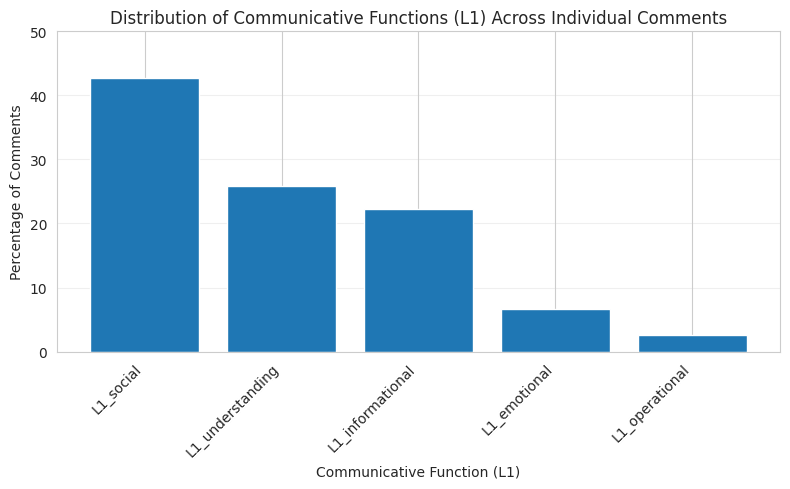


✓ Most common function: L1_social (42.7%)


In [ ]:
# L1 Distribution - Individual Comments
print("="*60)
print(f"L1 CODE DISTRIBUTION - INDIVIDUAL COMMENTS (n={len(comments_clean)})")
print("="*60)

# Compute counts and percentages
l1_counts = comments_clean['L1_code'].value_counts()
l1_pct = (l1_counts / len(comments_clean) * 100)

# Sort by prevalence (descending)
l1_pct = l1_pct.sort_values(ascending=False)
l1_counts = l1_counts[l1_pct.index]

# Summary table (useful for paper cross-checking)
l1_summary = pd.DataFrame({
    'Count': l1_counts,
    'Percentage': l1_pct.round(1)
})

print("\n", l1_summary)

# ---- Visualization (Bar Chart Only) ----
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    l1_pct.index,
    l1_pct.values
)

plt.ylabel('Percentage of Comments')
plt.xlabel('Communicative Function (L1)')
plt.ylim(0, 50)
plt.title('Distribution of Communicative Functions (L1) Across Individual Comments')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"\n✓ Most common function: "
    f"{l1_pct.index[0]} ({l1_pct.iloc[0]:.1f}%)"
)


L1 CODE DISTRIBUTION - CONVERSATIONS (n=200)

                   Count  Percentage
L1_code                            
L1_social            89        44.5
L1_understanding     70        35.0
L1_operational       23        11.5
L1_informational     18         9.0


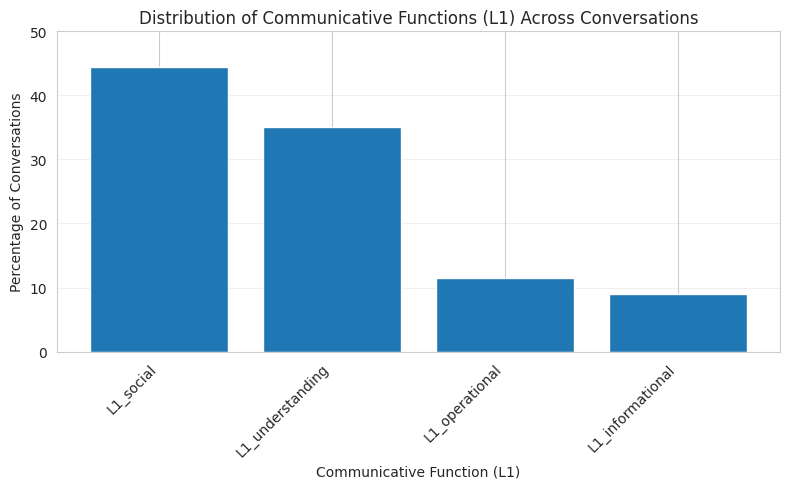

In [ ]:
# L1 Distribution – Conversations (conversation-level coding)

print("="*60)
print(f"L1 CODE DISTRIBUTION - CONVERSATIONS (n={n_unique_conversations})")
print("="*60)

# One row per conversation (conversation-level coding)
conv_unique = conversations_clean.drop_duplicates(subset='conversation_id')

# Compute counts and percentages
l1_conv_counts = conv_unique['L1_code'].value_counts()
l1_conv_pct = (l1_conv_counts / len(conv_unique) * 100)

# Sort by percentage (descending)
l1_conv_pct = l1_conv_pct.sort_values(ascending=False)

# Print summary table (optional, but useful)
l1_conv_summary = pd.DataFrame({
    'Count': l1_conv_counts[l1_conv_pct.index],
    'Percentage': l1_conv_pct.round(1)
})
print("\n", l1_conv_summary)

# ---- Visualization (Bar Chart Only) ----
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    l1_conv_pct.index,
    l1_conv_pct.values
)

plt.ylabel('Percentage of Conversations')
plt.xlabel('Communicative Function (L1)')
plt.ylim(0, 50)
plt.title('Distribution of Communicative Functions (L1) Across Conversations')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


COMPARISON: INDIVIDUAL COMMENTS vs CONVERSATIONS

                   Comments (%)  Conversations (%)  Difference
L1_code                                                      
L1_understanding     25.783620               35.0    9.216380
L1_operational        2.527806               11.5    8.972194
L1_social            42.719919               44.5    1.780081
L1_emotional          6.723964                0.0   -6.723964
L1_informational     22.244692                9.0  -13.244692


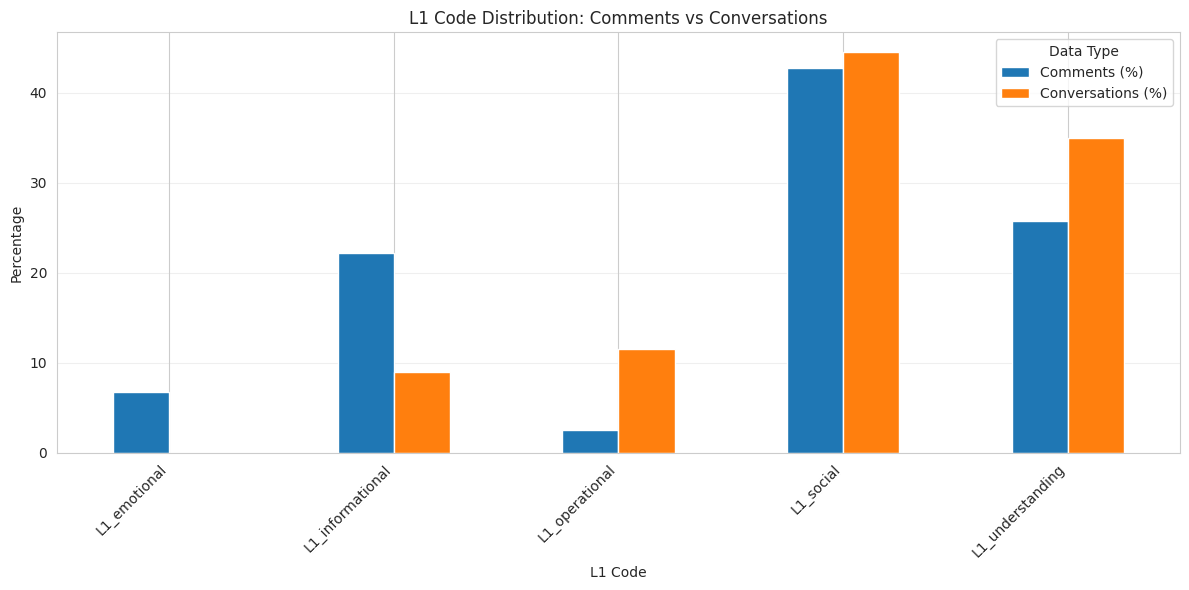


💡 INTERPRETATION:
Positive difference = more common in conversations
Negative difference = more common in individual comments


In [ ]:
# Compare Comments vs Conversations L1 distribution
print("="*60)
print("COMPARISON: INDIVIDUAL COMMENTS vs CONVERSATIONS")
print("="*60)

comparison_df = pd.DataFrame({
    'Comments (%)': l1_pct,
    'Conversations (%)': l1_conv_pct
}).fillna(0)

comparison_df['Difference'] = comparison_df['Conversations (%)'] - comparison_df['Comments (%)']

print("\n", comparison_df.sort_values('Difference', ascending=False))

# Visualize side-by-side
comparison_df[['Comments (%)', 'Conversations (%)']].plot(kind='bar', figsize=(12, 6))
plt.title('L1 Code Distribution: Comments vs Conversations')
plt.ylabel('Percentage')
plt.xlabel('L1 Code')
plt.legend(title='Data Type')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
print("Positive difference = more common in conversations")
print("Negative difference = more common in individual comments")

WORD COUNT BY L1 CODE

                   Mean  Median  Std  Min  Max
L1_code                                      
L1_informational   9.8     8.0  6.0    2   43
L1_operational     9.1     7.0  5.2    3   22
L1_social          8.7     7.0  6.8    2   44
L1_understanding   7.3     6.0  5.6    2   38
L1_emotional       6.5     5.0  5.5    2   35


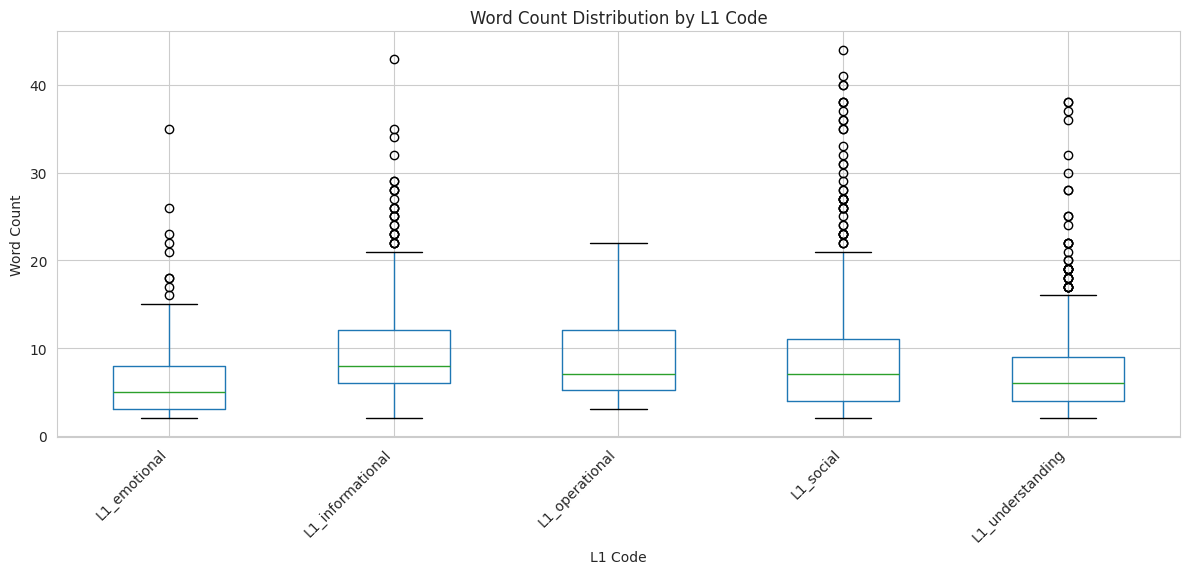


💡 INTERPRETATION: Which communicative functions are most verbose?


In [ ]:
# Word count by L1 category (are some functions more verbose?)
print("="*60)
print("WORD COUNT BY L1 CODE")
print("="*60)

wordcount_by_l1 = comments_clean.groupby('L1_code')['word_count'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(1)

print("\n", wordcount_by_l1.sort_values('Mean', ascending=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
comments_clean.boxplot(column='word_count', by='L1_code', ax=ax)
plt.suptitle('')
plt.title('Word Count Distribution by L1 Code')
plt.xlabel('L1 Code')
plt.ylabel('Word Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION: Which communicative functions are most verbose?")

---
## RQ2: How Trust-Signaling Behaviors Manifest

**How do trust-signaling behaviors (L2 codes) appear in this multi-functional ecology?**

This section examines:
1. Overall L2 prevalence
2. L2 distribution (which trust behaviors are most common?)
3. **L1 × L2 co-occurrence** (WHERE in the ecology does trust work happen?)

L2 CODE PREVALENCE - INDIVIDUAL COMMENTS

Comments WITH L2 code (trust work): 841 (42.5%)
Comments WITHOUT L2 code: 1,137 (57.5%)


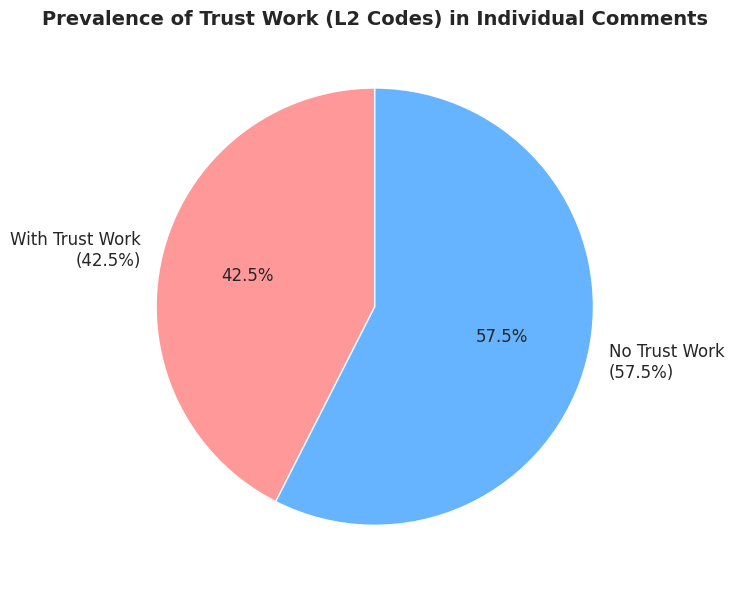


💡 KEY FINDING: What proportion of chat activity involves explicit trust work?


In [ ]:
# L2 Prevalence - What % of comments contain trust work?
print("="*60)
print("L2 CODE PREVALENCE - INDIVIDUAL COMMENTS")
print("="*60)

comments_with_l2 = comments_clean['L2_code'].notna().sum()
comments_without_l2 = comments_clean['L2_code'].isna().sum()
pct_with_l2 = (comments_with_l2 / len(comments_clean) * 100).round(1)

print(f"\nComments WITH L2 code (trust work): {comments_with_l2:,} ({pct_with_l2}%)")
print(f"Comments WITHOUT L2 code: {comments_without_l2:,} ({100-pct_with_l2}%)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
labels = [f'With Trust Work\n({pct_with_l2}%)', f'No Trust Work\n({100-pct_with_l2}%)']
sizes = [comments_with_l2, comments_without_l2]
colors = ['#ff9999', '#66b3ff']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 12})
ax.set_title('Prevalence of Trust Work (L2 Codes) in Individual Comments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY FINDING: What proportion of chat activity involves explicit trust work?")

L2 CODE PREVALENCE - CONVERSATIONS

Conversations WITH L2 code (trust work): 88 (44.0%)
Conversations WITHOUT L2 code: 112 (56.0%)


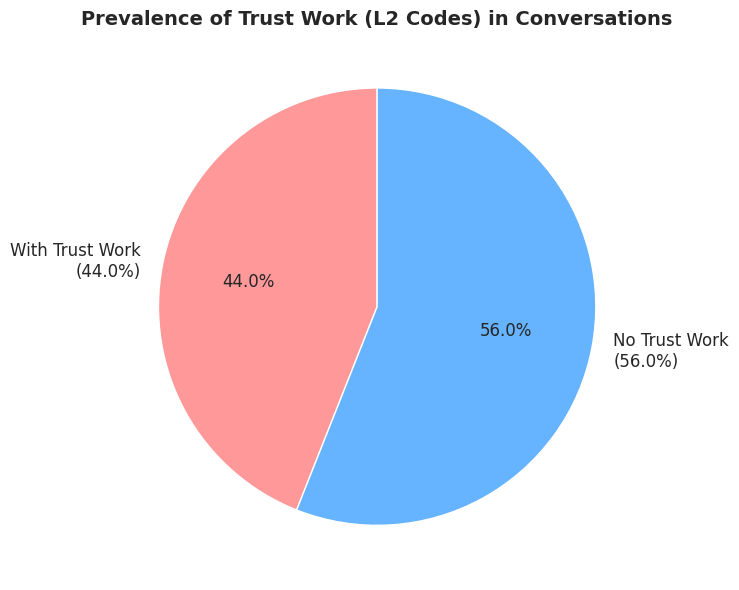

In [ ]:
# L2 Prevalence - Conversations
print("="*60)
print("L2 CODE PREVALENCE - CONVERSATIONS")
print("="*60)

conv_with_l2 = conv_unique['L2_code'].notna().sum()
conv_without_l2 = conv_unique['L2_code'].isna().sum()
pct_conv_with_l2 = (conv_with_l2 / len(conv_unique) * 100).round(1)

print(f"\nConversations WITH L2 code (trust work): {conv_with_l2} ({pct_conv_with_l2}%)")
print(f"Conversations WITHOUT L2 code: {conv_without_l2} ({100-pct_conv_with_l2}%)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
labels = [f'With Trust Work\n({pct_conv_with_l2}%)', f'No Trust Work\n({100-pct_conv_with_l2}%)']
sizes = [conv_with_l2, conv_without_l2]
colors = ['#ff9999', '#66b3ff']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 12})
ax.set_title('Prevalence of Trust Work (L2 Codes) in Conversations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

L2 CODE DISTRIBUTION - INDIVIDUAL COMMENTS

                      Count  % of All Comments  % of L2 Comments
L2_code                                                        
L2_creator_question    460               23.3              54.7
L2_ground_truth        253               12.8              30.1
L2_highlighting         67                3.4               8.0
L2_vouching             31                1.6               3.7
L2_repair               30                1.5               3.6


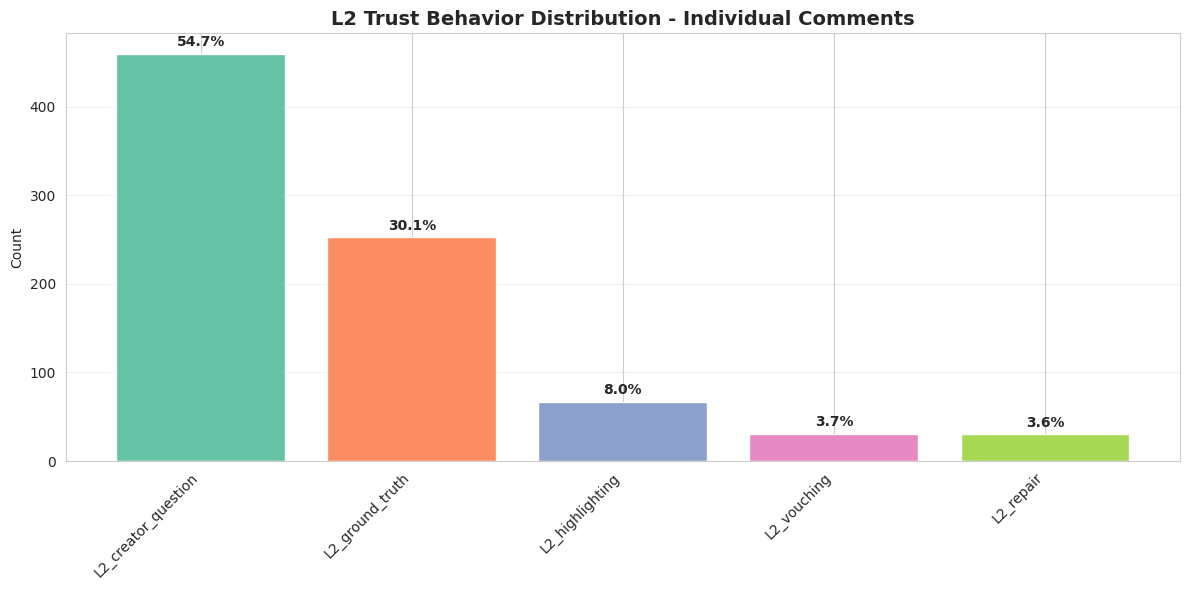


✓ Most common trust behavior: L2_creator_question (54.7% of trust work)


In [ ]:
# L2 Distribution - Which trust behaviors are most common?
print("="*60)
print("L2 CODE DISTRIBUTION - INDIVIDUAL COMMENTS")
print("="*60)

# Filter to only comments WITH L2 codes
comments_l2_only = comments_clean[comments_clean['L2_code'].notna()]

l2_counts = comments_l2_only['L2_code'].value_counts()
l2_pct_of_total = (l2_counts / len(comments_clean) * 100).round(1)
l2_pct_of_l2 = (l2_counts / len(comments_l2_only) * 100).round(1)

l2_summary = pd.DataFrame({
    'Count': l2_counts,
    '% of All Comments': l2_pct_of_total,
    '% of L2 Comments': l2_pct_of_l2
})

print("\n", l2_summary)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("Set2", len(l2_counts))
ax.bar(range(len(l2_counts)), l2_counts.values, color=colors)
ax.set_xticks(range(len(l2_counts)))
ax.set_xticklabels(l2_counts.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('L2 Trust Behavior Distribution - Individual Comments', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (count, pct) in enumerate(zip(l2_counts.values, l2_pct_of_l2.values)):
    ax.text(i, count + 5, f'{pct}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Most common trust behavior: {l2_counts.index[0]} ({l2_pct_of_l2.iloc[0]}% of trust work)")

L2 CODE DISTRIBUTION - CONVERSATIONS

                      Count  % of All Conversations  % of L2 Conversations
L2_code                                                                  
L2_creator_question     59                    29.5                   67.0
L2_ground_truth         14                     7.0                   15.9
L2_repair                8                     4.0                    9.1
L2_vouching              7                     3.5                    8.0


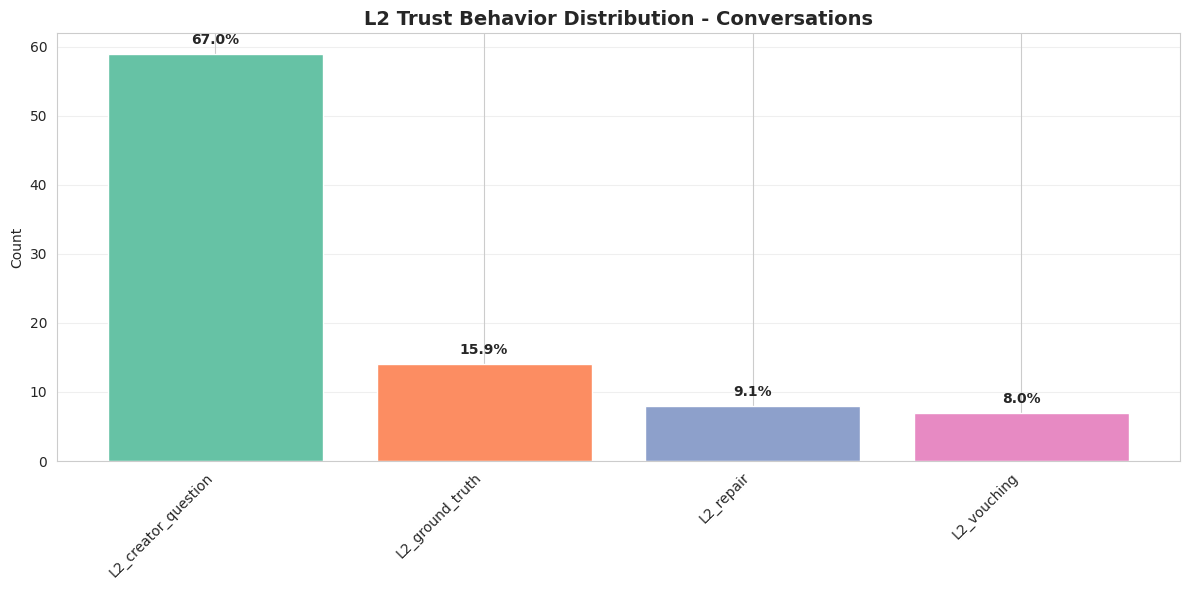

In [ ]:
# L2 Distribution - Conversations
print("="*60)
print("L2 CODE DISTRIBUTION - CONVERSATIONS")
print("="*60)

# Filter to only conversations WITH L2 codes
conv_l2_only = conv_unique[conv_unique['L2_code'].notna()]

l2_conv_counts = conv_l2_only['L2_code'].value_counts()
l2_conv_pct_of_total = (l2_conv_counts / len(conv_unique) * 100).round(1)
l2_conv_pct_of_l2 = (l2_conv_counts / len(conv_l2_only) * 100).round(1)

l2_conv_summary = pd.DataFrame({
    'Count': l2_conv_counts,
    '% of All Conversations': l2_conv_pct_of_total,
    '% of L2 Conversations': l2_conv_pct_of_l2
})

print("\n", l2_conv_summary)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("Set2", len(l2_conv_counts))
ax.bar(range(len(l2_conv_counts)), l2_conv_counts.values, color=colors)
ax.set_xticks(range(len(l2_conv_counts)))
ax.set_xticklabels(l2_conv_counts.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('L2 Trust Behavior Distribution - Conversations', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (count, pct) in enumerate(zip(l2_conv_counts.values, l2_conv_pct_of_l2.values)):
    ax.text(i, count + 1, f'{pct}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

TEMPORAL PATTERNS: L2 Trust Work Over Event Duration

------------------------------------------------------------
L2 PREVALENCE BY TIME PERIOD
------------------------------------------------------------

           Total Comments  Comments with L2  % with L2
time_bin                                             
0-30min           1978.0             841.0       42.5
30-60min             0.0               0.0        NaN
1-2hr                0.0               0.0        NaN
2-4hr                0.0               0.0        NaN
4hr+                 0.0               0.0        NaN

------------------------------------------------------------
L2 CODE COMPOSITION ACROSS TIME
------------------------------------------------------------
(% distribution of each L2 code within each time period)

 L2_code   L2_creator_question  L2_ground_truth  L2_highlighting  L2_repair  \
time_bin                                                                     
0-30min                  54.7             30.

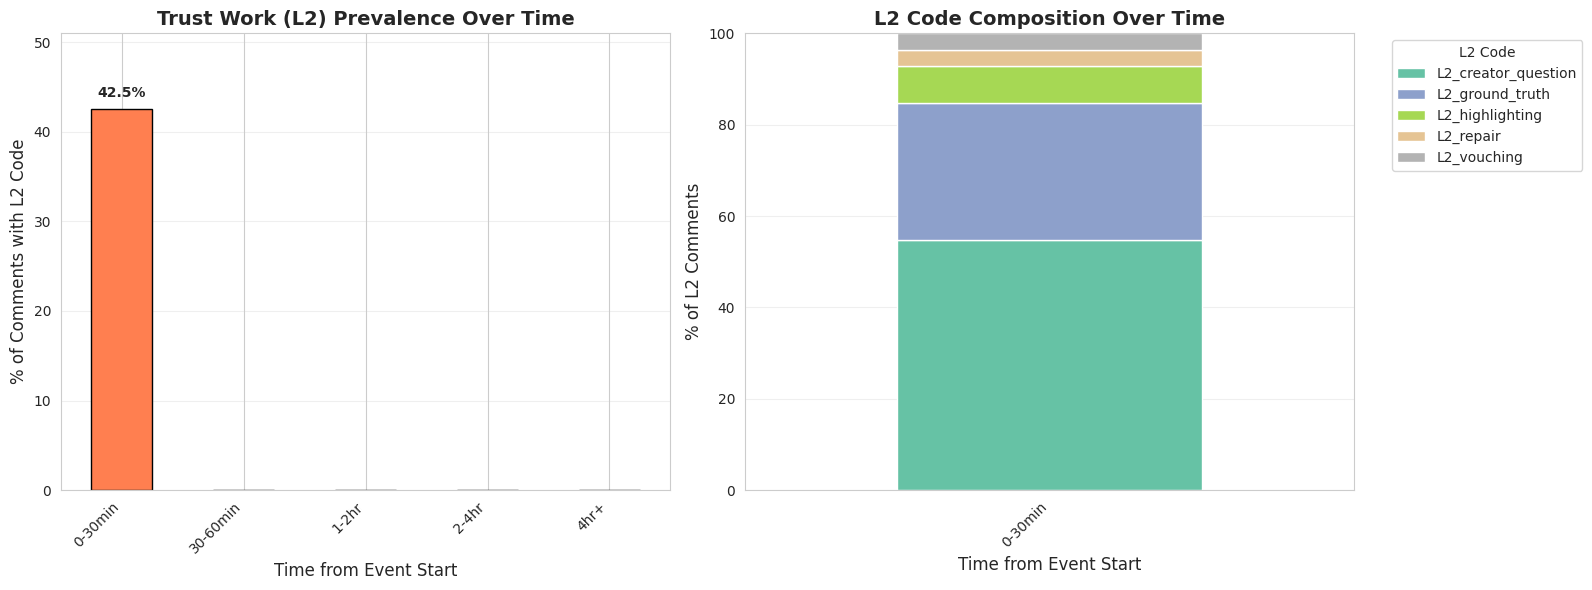


------------------------------------------------------------
TEMPORAL PATTERNS SUMMARY
------------------------------------------------------------

Overall L2 prevalence:
  Early periods (0-60min): nan%
  Late periods (2hr+): nan%
  → Trust work decreases over time (difference: nan%)

L2 code temporal shifts:

💡 KEY QUESTIONS:
- Is trust work constant (continuous substrate) or variable (response to uncertainty)?
- Do certain trust behaviors (vouching, repair) peak at different event phases?
- Does early trust work differ from late trust work?


In [ ]:
# ============================================================================
# TEMPORAL ANALYSIS: How Trust Work Changes Over Time
# ============================================================================

print("="*60)
print("TEMPORAL PATTERNS: L2 Trust Work Over Event Duration")
print("="*60)

if 'time_from_event_start' in comments_clean.columns:
    # Convert to hours
    comments_clean['hours_from_start'] = comments_clean['time_from_event_start'] / 3600

    # Create time bins
    comments_clean['time_bin'] = pd.cut(
        comments_clean['hours_from_start'],
        bins=[0, 0.5, 1, 2, 4, 24],
        labels=['0-30min', '30-60min', '1-2hr', '2-4hr', '4hr+'],
        include_lowest=True
    )

    # Overall L2 prevalence by time period
    print("\n" + "-"*60)
    print("L2 PREVALENCE BY TIME PERIOD")
    print("-"*60)

    l2_by_time = comments_clean.groupby('time_bin').apply(
        lambda x: pd.Series({
            'Total Comments': len(x),
            'Comments with L2': x['L2_code'].notna().sum(),
            '% with L2': (x['L2_code'].notna().sum() / len(x) * 100).round(1)
        })
    )

    print("\n", l2_by_time)

    # Which L2 codes appear when? (composition over time)
    print("\n" + "-"*60)
    print("L2 CODE COMPOSITION ACROSS TIME")
    print("-"*60)
    print("(% distribution of each L2 code within each time period)")

    l2_comments_with_time = comments_clean[comments_clean['L2_code'].notna()].copy()

    if len(l2_comments_with_time) > 0:
        l2_time_dist = pd.crosstab(
            l2_comments_with_time['time_bin'],
            l2_comments_with_time['L2_code'],
            normalize='index'
        ) * 100

        print("\n", l2_time_dist.round(1))

        # Visualizations
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Left plot: L2 prevalence over time (line/bar chart)
        l2_by_time['% with L2'].plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
        ax1.set_title('Trust Work (L2) Prevalence Over Time', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Time from Event Start', fontsize=12)
        ax1.set_ylabel('% of Comments with L2 Code', fontsize=12)
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
        ax1.grid(axis='y', alpha=0.3)
        ax1.set_ylim(0, max(l2_by_time['% with L2']) * 1.2)

        # Add value labels on bars
        for i, v in enumerate(l2_by_time['% with L2']):
            ax1.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

        # Right plot: L2 composition over time (stacked bar)
        l2_time_dist.plot(kind='bar', stacked=True, ax=ax2,
                          colormap='Set2', edgecolor='white', linewidth=1)
        ax2.set_title('L2 Code Composition Over Time', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Time from Event Start', fontsize=12)
        ax2.set_ylabel('% of L2 Comments', fontsize=12)
        ax2.legend(title='L2 Code', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
        ax2.grid(axis='y', alpha=0.3)
        ax2.set_ylim(0, 100)

        plt.tight_layout()
        plt.show()

        # Identify temporal patterns
        print("\n" + "-"*60)
        print("TEMPORAL PATTERNS SUMMARY")
        print("-"*60)

        # Check if L2 prevalence is stable or changing
        l2_pcts = l2_by_time['% with L2'].values
        early_avg = l2_pcts[:2].mean() if len(l2_pcts) >= 2 else l2_pcts[0]
        late_avg = l2_pcts[-2:].mean() if len(l2_pcts) >= 2 else l2_pcts[-1]

        print(f"\nOverall L2 prevalence:")
        print(f"  Early periods (0-60min): {early_avg:.1f}%")
        print(f"  Late periods (2hr+): {late_avg:.1f}%")

        if abs(early_avg - late_avg) < 5:
            print(f"  → Relatively stable over time (difference: {abs(early_avg - late_avg):.1f}%)")
        else:
            direction = "increases" if late_avg > early_avg else "decreases"
            print(f"  → Trust work {direction} over time (difference: {abs(early_avg - late_avg):.1f}%)")

        # Identify codes that peak early vs late
        print(f"\nL2 code temporal shifts:")
        for l2_code in l2_time_dist.columns:
            early_pct = l2_time_dist[l2_code].iloc[0] if len(l2_time_dist) > 0 else 0
            late_pct = l2_time_dist[l2_code].iloc[-1] if len(l2_time_dist) > 0 else 0

            if abs(early_pct - late_pct) > 5:
                direction = "increases" if late_pct > early_pct else "decreases"
                print(f"  {l2_code}: {direction} from {early_pct:.1f}% → {late_pct:.1f}%")

        print("\n💡 KEY QUESTIONS:")
        print("- Is trust work constant (continuous substrate) or variable (response to uncertainty)?")
        print("- Do certain trust behaviors (vouching, repair) peak at different event phases?")
        print("- Does early trust work differ from late trust work?")

    else:
        print("\n⚠️ Not enough L2 comments with time data for temporal analysis")

else:
    print("\n⚠️ 'time_from_event_start' column not found in comments_clean")
    print("Temporal analysis requires timestamp data.")

---
## RQ2b: L1 × L2 Co-Occurrence Analysis

**WHERE in the communication ecology does trust work appear?**

This is the **KEY ANALYSIS** for understanding how trust work is embedded within different communicative functions.

In [ ]:
# Create L1 × L2 contingency table
print("="*60)
print("L1 × L2 CO-OCCURRENCE HEATMAP - INDIVIDUAL COMMENTS")
print("="*60)

# Create a copy with 'No L2' for missing values
comments_heatmap = comments_clean.copy()
comments_heatmap['L2_code'] = comments_heatmap['L2_code'].fillna('No_L2')

# Create contingency table (crosstab)
contingency_table = pd.crosstab(comments_heatmap['L1_code'],
                                  comments_heatmap['L2_code'],
                                  margins=True)

print("\nRaw Counts:")
print(contingency_table)

# Create percentage table (% within each L1 category)
contingency_pct = pd.crosstab(comments_heatmap['L1_code'],
                                comments_heatmap['L2_code'],
                                normalize='index') * 100

print("\n\nPercentage (% within each L1 category):")
print(contingency_pct.round(1))

L1 × L2 CO-OCCURRENCE HEATMAP - INDIVIDUAL COMMENTS

Raw Counts:
L2_code           L2_creator_question  L2_ground_truth  L2_highlighting  \
L1_code                                                                   
L1_emotional                        0                4                0   
L1_informational                    0              227               48   
L1_operational                      3                3                0   
L1_social                           7               14                6   
L1_understanding                  450                5               13   
All                               460              253               67   

L2_code           L2_repair  L2_vouching  No_L2   All  
L1_code                                                
L1_emotional              0            0    129   133  
L1_informational         24            2    139   440  
L1_operational            2            0     42    50  
L1_social                 4           29    785   845 

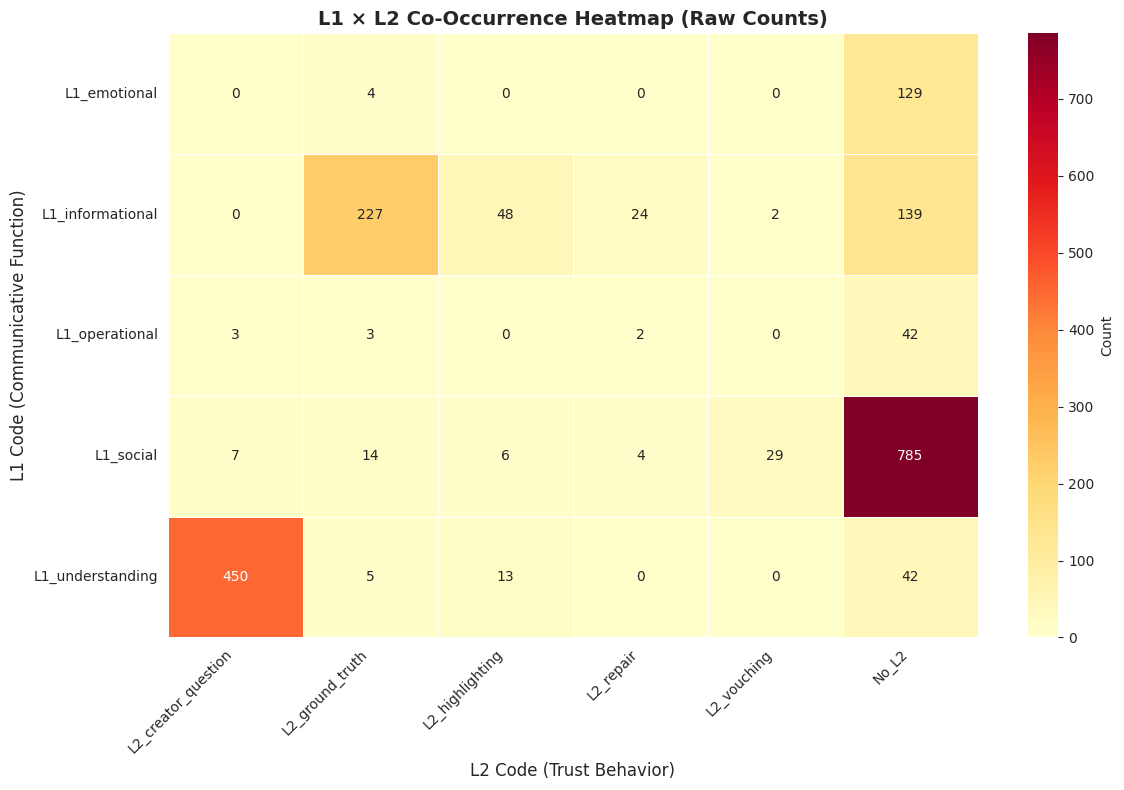


💡 INTERPRETATION: Darker cells = more co-occurrence
This shows WHERE trust work happens in the communication ecology


In [ ]:
# Visualize L1 × L2 Heatmap (RAW COUNTS)
# Remove margins for visualization
contingency_viz = contingency_table.drop('All', axis=0).drop('All', axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(contingency_viz, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.title('L1 × L2 Co-Occurrence Heatmap (Raw Counts)', fontsize=14, fontweight='bold')
plt.xlabel('L2 Code (Trust Behavior)', fontsize=12)
plt.ylabel('L1 Code (Communicative Function)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION: Darker cells = more co-occurrence")
print("This shows WHERE trust work happens in the communication ecology")

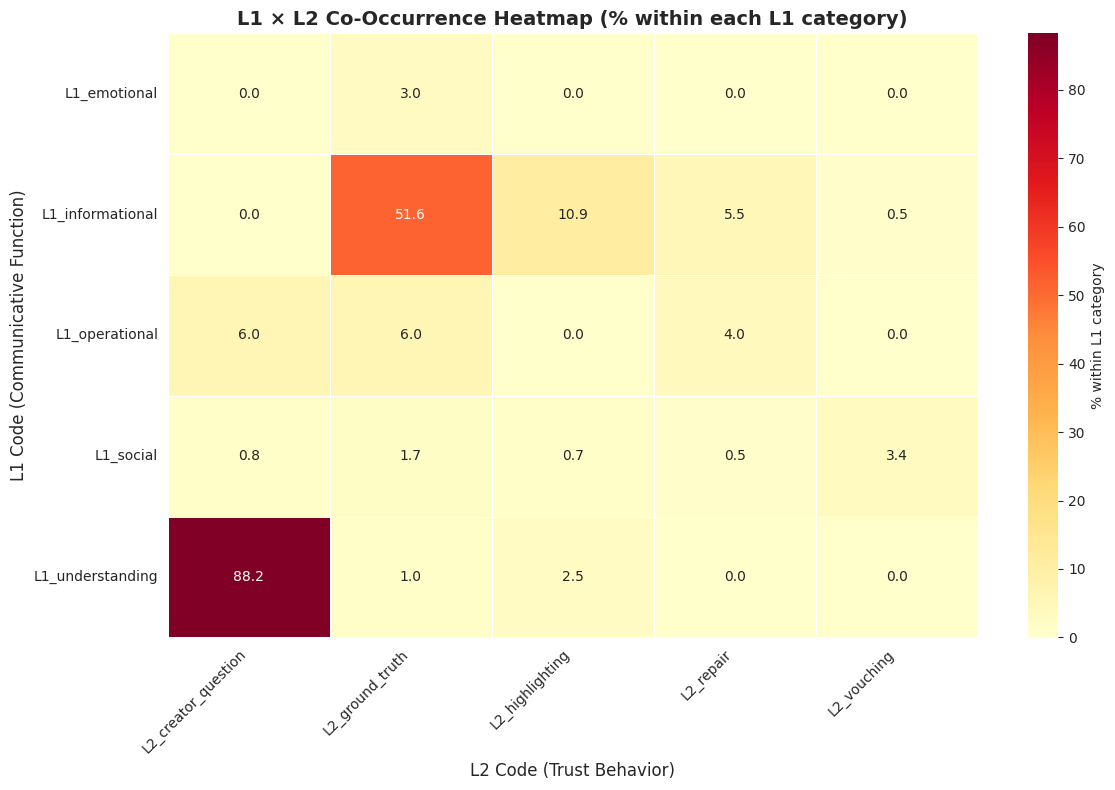


💡 INTERPRETATION: Numbers show % of comments in each L1 category
Example: '15.0' in L1_understanding × L2_creator_question = 
         15% of all 'understanding' comments involve creator questions


In [ ]:
# Visualize L1 × L2 Heatmap (PERCENTAGES)
# Remove No_L2 column for clearer visualization of trust work
contingency_pct_viz = contingency_pct.drop('No_L2', axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(contingency_pct_viz, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% within L1 category'}, linewidths=0.5)
plt.title('L1 × L2 Co-Occurrence Heatmap (% within each L1 category)', fontsize=14, fontweight='bold')
plt.xlabel('L2 Code (Trust Behavior)', fontsize=12)
plt.ylabel('L1 Code (Communicative Function)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION: Numbers show % of comments in each L1 category")
print("Example: '15.0' in L1_understanding × L2_creator_question = ")
print("         15% of all 'understanding' comments involve creator questions")

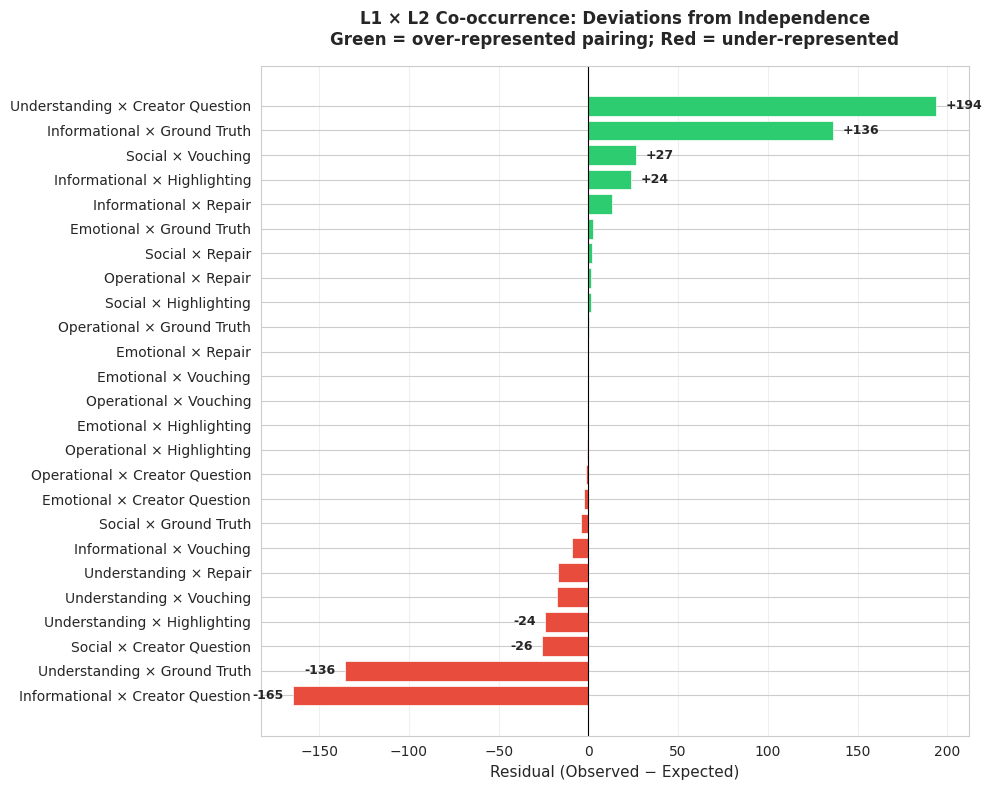


χ²(16) = 1114.66, p = 0.000000

💡 Reading guide:
  • Bars to the right of zero = pairings that occurred MORE than chance
  • Bars to the left of zero = pairings that occurred LESS than chance
  • The three pathways: Understanding→Creator Question (+194),
    Informational→Ground Truth (+136), Social→Vouching (+27)


In [ ]:
# ============================================================
# RESIDUALS CHART — visualizes the three pathways finding
# Self-contained: recomputes residuals from comments_clean
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

# Recompute contingency table and residuals (independent of Cell 27)
comments_l2 = comments_clean[comments_clean['L2_code'].notna()]
contingency = pd.crosstab(comments_l2['L1_code'], comments_l2['L2_code'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
residuals_df = pd.DataFrame(
    contingency.values - expected,
    index=contingency.index,
    columns=contingency.columns
)

# Strip the L1_/L2_ prefixes for clean labels
plot_df = residuals_df.copy()
plot_df.index = plot_df.index.str.replace('L1_', '', regex=False).str.title()
plot_df.columns = plot_df.columns.str.replace('L2_', '', regex=False).str.replace('_', ' ').str.title()

# Flatten to long format and sort by residual magnitude
flat = []
for l1 in plot_df.index:
    for l2 in plot_df.columns:
        flat.append({'pair': f'{l1} × {l2}', 'residual': plot_df.loc[l1, l2]})
flat_df = pd.DataFrame(flat).sort_values('residual', ascending=True)

# Color: green for positive (over-represented), red for negative
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in flat_df['residual']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(flat_df['pair'], flat_df['residual'], color=colors, edgecolor='white', linewidth=0.5)

# Reference line at 0
ax.axvline(0, color='black', linewidth=0.8)

# Annotate the most extreme bars with their residual values
for bar, r in zip(bars, flat_df['residual']):
    if abs(r) >= 20:
        x_pos = bar.get_width()
        offset = 5 if r > 0 else -5
        ha = 'left' if r > 0 else 'right'
        ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
                f'{r:+.0f}', ha=ha, va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Residual (Observed − Expected)', fontsize=11)
ax.set_title('L1 × L2 Co-occurrence: Deviations from Independence\n'
             'Green = over-represented pairing; Red = under-represented',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('L1_L2_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nχ²({dof}) = {chi2:.2f}, p = {p_value:.6f}")
print("\n💡 Reading guide:")
print("  • Bars to the right of zero = pairings that occurred MORE than chance")
print("  • Bars to the left of zero = pairings that occurred LESS than chance")
print("  • The three pathways: Understanding→Creator Question (+194),")
print("    Informational→Ground Truth (+136), Social→Vouching (+27)")

In [ ]:
# Statistical test: Chi-square test of independence
print("="*60)
print("CHI-SQUARE TEST: Are L1 and L2 codes independent?")
print("="*60)

# Use only L2 comments (exclude No_L2) for more meaningful test
comments_l2_test = comments_clean[comments_clean['L2_code'].notna()]
contingency_test = pd.crosstab(comments_l2_test['L1_code'], comments_l2_test['L2_code'])

chi2, p_value, dof, expected = chi2_contingency(contingency_test)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.001:
    print("\n✓ RESULT: Highly significant (p < 0.001)")
    print("   L1 and L2 codes are NOT independent.")
    print("   Trust behaviors co-occur non-randomly with communicative functions.")
elif p_value < 0.05:
    print("\n✓ RESULT: Significant (p < 0.05)")
    print("   L1 and L2 codes are NOT independent.")
else:
    print("\n✗ RESULT: Not significant (p >= 0.05)")
    print("   Cannot reject independence.")

print("\n💡 PLAIN LANGUAGE:")
print("This test asks: Do trust behaviors appear randomly across all message types,")
print("or do they cluster in specific communicative functions?")
print("If p < 0.05, trust work is systematically embedded in particular functions.")

CHI-SQUARE TEST: Are L1 and L2 codes independent?

Chi-square statistic: 1114.66
Degrees of freedom: 16
P-value: 0.000000

✓ RESULT: Highly significant (p < 0.001)
   L1 and L2 codes are NOT independent.
   Trust behaviors co-occur non-randomly with communicative functions.

💡 PLAIN LANGUAGE:
This test asks: Do trust behaviors appear randomly across all message types,
or do they cluster in specific communicative functions?
If p < 0.05, trust work is systematically embedded in particular functions.


In [ ]:
# Calculate Cramér's V (effect size for chi-square)
from scipy.stats.contingency import association

cramers_v = association(contingency_test, method="cramer")

print("\n" + "="*60)
print("EFFECT SIZE: Cramér's V")
print("="*60)

print(f"\nCramér's V: {cramers_v:.3f}")

# Interpretation guidelines (for df > 1)
if cramers_v < 0.1:
    strength = "negligible"
    color = "⚪"
elif cramers_v < 0.3:
    strength = "small"
    color = "🟡"
elif cramers_v < 0.5:
    strength = "moderate"
    color = "🟠"
else:
    strength = "strong"
    color = "🔴"

print(f"Effect size: {strength} {color}")

print("\n💡 INTERPRETATION:")
print("Cramér's V measures the strength of association between L1 and L2 codes.")
print("  V < 0.1  = negligible effect")
print("  V = 0.1-0.3  = small effect")
print("  V = 0.3-0.5  = moderate effect")
print("  V > 0.5  = strong effect")

print("\n📝 FOR YOUR PAPER:")
print(f"\"A chi-square test revealed a significant association between communicative")
print(f"function (L1) and trust behavior (L2), χ²({dof}) = {chi2:.2f}, p < .001,")
print(f"Cramér's V = {cramers_v:.2f}, indicating a {strength} effect.\"")


EFFECT SIZE: Cramér's V

Cramér's V: 0.576
Effect size: strong 🔴

💡 INTERPRETATION:
Cramér's V measures the strength of association between L1 and L2 codes.
  V < 0.1  = negligible effect
  V = 0.1-0.3  = small effect
  V = 0.3-0.5  = moderate effect
  V > 0.5  = strong effect

📝 FOR YOUR PAPER:
"A chi-square test revealed a significant association between communicative
function (L1) and trust behavior (L2), χ²(16) = 1114.66, p < .001,
Cramér's V = 0.58, indicating a strong effect."


In [ ]:
# Show expected vs observed for interesting cells
print("\n" + "="*60)
print("EXPECTED vs OBSERVED FREQUENCIES (Top Differences)")
print("="*60)

# Calculate residuals (observed - expected)
observed = contingency_test.values
residuals = observed - expected

# Create dataframe of residuals
residuals_df = pd.DataFrame(residuals,
                             index=contingency_test.index,
                             columns=contingency_test.columns)

# Flatten and sort by absolute value
residuals_flat = []
for l1 in residuals_df.index:
    for l2 in residuals_df.columns:
        residuals_flat.append({
            'L1': l1,
            'L2': l2,
            'Observed': contingency_test.loc[l1, l2],
            'Expected': expected[contingency_test.index.get_loc(l1),
                                 contingency_test.columns.get_loc(l2)],
            'Residual': residuals_df.loc[l1, l2]
        })

residuals_summary = pd.DataFrame(residuals_flat)
residuals_summary = residuals_summary.sort_values('Residual', key=abs, ascending=False)

print("\nTop 10 largest deviations from expected:")
print(residuals_summary.head(10).to_string(index=False))

print("\n💡 INTERPRETATION:")
print("Positive residual = MORE co-occurrence than expected by chance")
print("Negative residual = LESS co-occurrence than expected by chance")
print("Large residuals indicate systematic patterns, not random distribution")


EXPECTED vs OBSERVED FREQUENCIES (Top Differences)

Top 10 largest deviations from expected:
              L1                  L2  Observed   Expected    Residual
L1_understanding L2_creator_question       450 255.980975  194.019025
L1_informational L2_creator_question         0 164.637337 -164.637337
L1_informational     L2_ground_truth       227  90.550535  136.449465
L1_understanding     L2_ground_truth         5 140.789536 -135.789536
       L1_social         L2_vouching        29   2.211653   26.788347
       L1_social L2_creator_question         7  32.818074  -25.818074
L1_understanding     L2_highlighting        13  37.284185  -24.284185
L1_informational     L2_highlighting        48  23.979786   24.020214
L1_understanding         L2_vouching         0  17.250892  -17.250892
L1_understanding           L2_repair         0  16.694411  -16.694411

💡 INTERPRETATION:
Positive residual = MORE co-occurrence than expected by chance
Negative residual = LESS co-occurrence than expected b

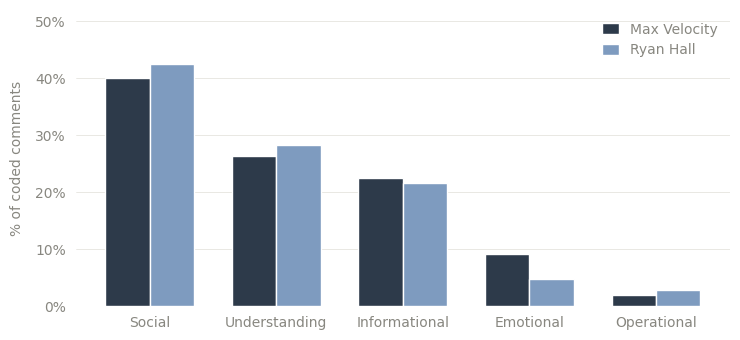

✓ Figure B saved


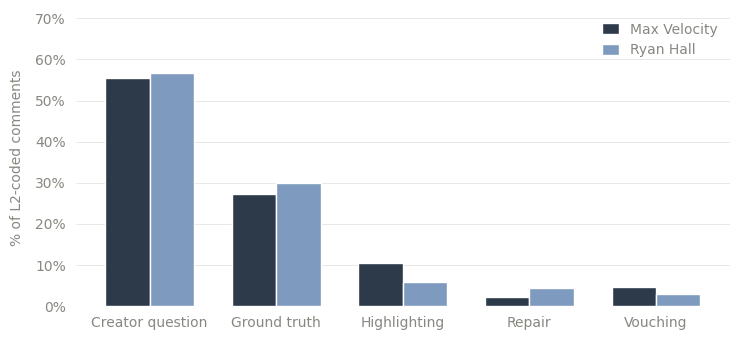

✓ Figure C saved


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# PUBLICATION FIGURES B & C — Creator-level L1 and L2 comparisons
# Requires: comments_clean (from Cell 9)
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DARK  = '#2D3A4A'
LIGHT = '#7E9BBF'
MUTED = '#888780'

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': False,
    'axes.grid': True, 'grid.color': '#E0DED8', 'grid.linewidth': 0.5,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.bottom': False, 'ytick.left': False,
})

# Compute L1 distributions from data
l1_order = ['L1_social', 'L1_understanding', 'L1_informational', 'L1_emotional', 'L1_operational']
l1_labels = ['Social', 'Understanding', 'Informational', 'Emotional', 'Operational']

def l1_pcts(creator):
    sub = comments_clean[comments_clean['creator'] == creator]
    counts = sub['L1_code'].value_counts()
    return [(counts.get(c, 0) / len(sub) * 100) for c in l1_order]

l1_max  = l1_pcts('max')
l1_ryan = l1_pcts('ryan')

# ── Figure B: L1 by creator ──────────────────────────────────────────────

x = np.arange(len(l1_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.bar(x - w/2, l1_max,  w, label='Max Velocity', color=DARK,  zorder=3)
ax.bar(x + w/2, l1_ryan, w, label='Ryan Hall',    color=LIGHT, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(l1_labels, fontsize=10, color=MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_ylim(0, 52)
ax.grid(axis='y', zorder=0)
ax.grid(axis='x', visible=False)
ax.tick_params(colors=MUTED, labelsize=10)
ax.set_ylabel('% of coded comments', fontsize=10, color=MUTED, labelpad=8)
ax.legend(frameon=False, fontsize=10, labelcolor=MUTED,
          loc='upper right', handlelength=1.2, handleheight=0.8)

#fig.suptitle('Figure B — Communicative function distribution by creator (L1)',
             #x=0, y=1.03, ha='left', fontsize=11, color=DARK)
#fig.text(0, -0.05,
         #'L1 communicative function distribution across the two primary creators. '
         #'Statistical differences present but substantively small (χ²(4) = 14.28, p = .007, V = 0.09).',
         #fontsize=9, color=MUTED, style='italic')

plt.tight_layout()
plt.savefig('fig_B_l1_by_creator.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure B saved")

# Compute L2 distributions from data
l2_order  = ['L2_creator_question', 'L2_ground_truth', 'L2_highlighting',
             'L2_repair', 'L2_vouching']
l2_labels = ['Creator question', 'Ground truth', 'Highlighting', 'Repair', 'Vouching']

def l2_pcts(creator):
    sub = comments_clean[(comments_clean['creator'] == creator) &
                         (comments_clean['L2_code'].notna())]
    counts = sub['L2_code'].value_counts()
    return [(counts.get(c, 0) / len(sub) * 100) for c in l2_order]

l2_max  = l2_pcts('max')
l2_ryan = l2_pcts('ryan')

# ── Figure C: L2 by creator ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.bar(x - w/2, l2_max,  w, label='Max Velocity', color=DARK,  zorder=3)
ax.bar(x + w/2, l2_ryan, w, label='Ryan Hall',    color=LIGHT, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(l2_labels, fontsize=10, color=MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_ylim(0, 72)
ax.grid(axis='y', zorder=0)
ax.grid(axis='x', visible=False)
ax.tick_params(colors=MUTED, labelsize=10)
ax.set_ylabel('% of L2-coded comments', fontsize=10, color=MUTED, labelpad=8)
ax.legend(frameon=False, fontsize=10, labelcolor=MUTED,
          loc='upper right', handlelength=1.2, handleheight=0.8)

#fig.suptitle('Figure C — Trust behavior distribution by creator (L2, % of L2-coded comments)',
             #x=0, y=1.03, ha='left', fontsize=11, color=DARK)
#fig.text(0, -0.05,
         #'Distribution of trust-signaling behaviors as a proportion of L2-coded comments per creator. '
         #'Dominant pathways were consistent across both chats.',
         #fontsize=9, color=MUTED, style='italic')

plt.tight_layout()
plt.savefig('fig_B_l1_by_creator.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure C saved")

---
## RQ3: Conversation-Level Patterns

**What do behavioral patterns reveal about how collective trust operates?**

Moving from "atoms" (individual codes) to "organisms" (conversation sequences)

CONVERSATION LENGTH DISTRIBUTION

Conversation length statistics (# of messages):
  Mean: 3.6
  Median: 3.0
  Std: 1.5
  Min: 2.0
  Max: 16.0

Distribution by conversation length:
  2 messages: 3 conversations (1.5%)
  3 messages: 144 conversations (72.0%)
  4 messages: 25 conversations (12.5%)
  5 messages: 11 conversations (5.5%)
  6 messages: 7 conversations (3.5%)
  7 messages: 5 conversations (2.5%)
  8 messages: 2 conversations (1.0%)
  9 messages: 1 conversations (0.5%)
  10 messages: 1 conversations (0.5%)
  16 messages: 1 conversations (0.5%)


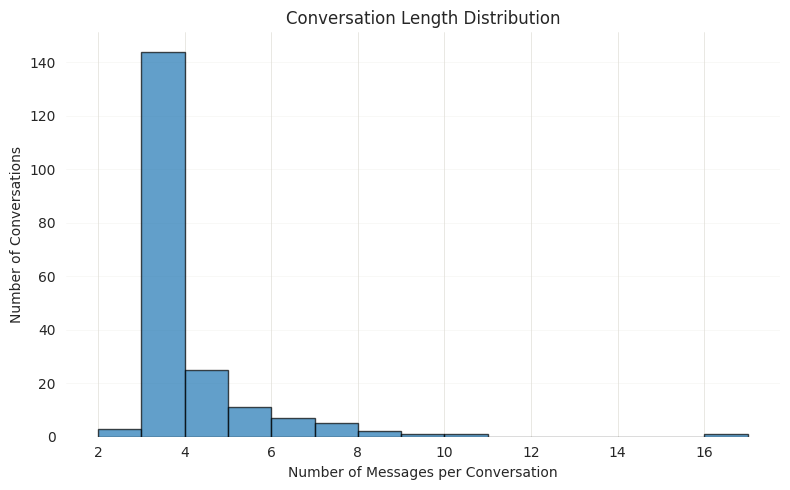


KEY QUESTION: Are most conversations brief exchanges or extended discussions?


In [ ]:
# Conversation length distribution
print("="*60)
print("CONVERSATION LENGTH DISTRIBUTION")
print("="*60)

# Compute conversation lengths
conv_lengths = conversations_clean.groupby('conversation_id').size()

# Descriptive statistics
length_stats = {
    'Mean': conv_lengths.mean(),
    'Median': conv_lengths.median(),
    'Std': conv_lengths.std(),
    'Min': conv_lengths.min(),
    'Max': conv_lengths.max()
}

print("\nConversation length statistics (# of messages):")
for stat, value in length_stats.items():
    print(f"  {stat}: {value:.1f}")

# Distribution of conversation lengths
length_distribution = conv_lengths.value_counts().sort_index()
print("\nDistribution by conversation length:")
for length, count in length_distribution.items():
    pct = (count / len(conv_lengths) * 100)
    print(f"  {length} messages: {count} conversations ({pct:.1f}%)")

# ---- Visualization: Histogram Only ----
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    conv_lengths,
    bins=range(conv_lengths.min(), conv_lengths.max() + 2),
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('Number of Messages per Conversation')
plt.ylabel('Number of Conversations')
plt.title('Conversation Length Distribution')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKEY QUESTION: Are most conversations brief exchanges or extended discussions?")


In [ ]:
# Analyze message-level codes WITHIN conversations
# Even though conversations are coded at the conversation_id level,
# we can examine message-level patterns within them

print("="*60)
print("MESSAGE-LEVEL PATTERNS WITHIN CONVERSATIONS")
print("="*60)

# Check if conversations have message-level codes
if 'L1_code' in conversations_clean.columns:
    print("\n⚠️ Note: This analysis examines conversation-LEVEL codes")
    print("(All messages in a conversation receive the same L1/L2 code)\n")

    # Group by conversation_id and check if codes are uniform within conversations
    code_uniformity = conversations_clean.groupby('conversation_id').agg({
        'L1_code': lambda x: x.nunique() == 1,
        'L2_code': lambda x: x.nunique() == 1 or x.isna().all()
    })

    all_uniform_l1 = code_uniformity['L1_code'].all()
    all_uniform_l2 = code_uniformity['L2_code'].all()

    print(f"L1 codes uniform within conversations: {all_uniform_l1}")
    print(f"L2 codes uniform within conversations: {all_uniform_l2}")

    if all_uniform_l1 and all_uniform_l2:
        print("\n✓ Confirmed: Codes are applied at the conversation level")
        print("  (not individual message level)")

MESSAGE-LEVEL PATTERNS WITHIN CONVERSATIONS

⚠️ Note: This analysis examines conversation-LEVEL codes
(All messages in a conversation receive the same L1/L2 code)

L1 codes uniform within conversations: True
L2 codes uniform within conversations: True

✓ Confirmed: Codes are applied at the conversation level
  (not individual message level)


CONVERSATION LENGTH BY L1 CODE

                   Count  Mean Length  Median Length  Max Length
L1_code                                                        
L1_informational     18          3.4            3.0           5
L1_operational       23          3.5            3.0           7
L1_social            89          3.7            3.0          16
L1_understanding     70          3.6            3.0          10


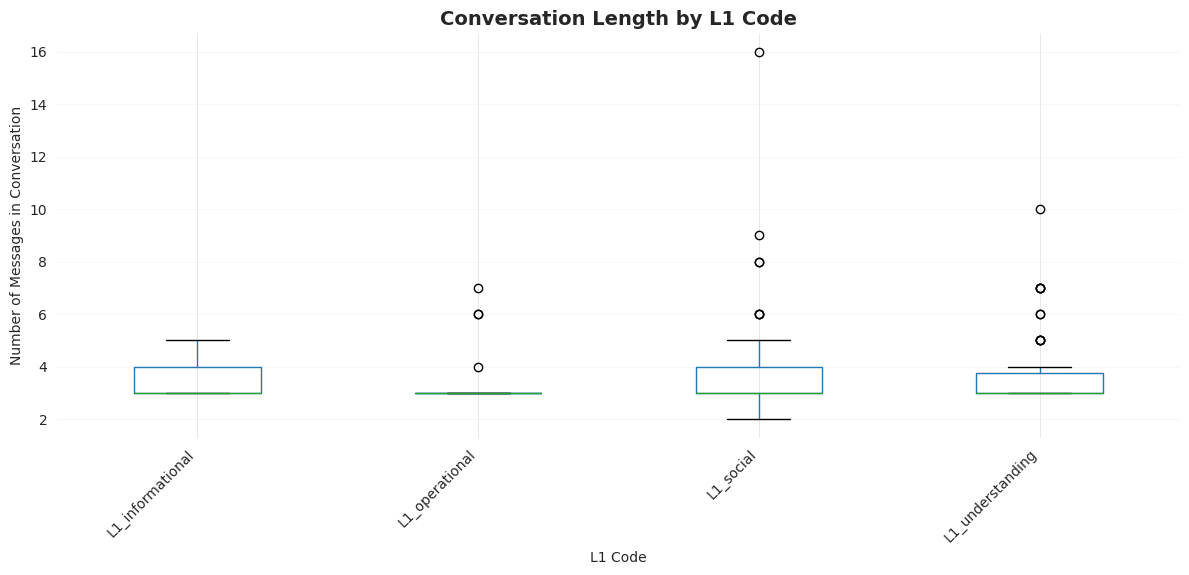


💡 KEY QUESTION: Do certain communicative functions generate longer exchanges?


In [ ]:
# Analyze conversation patterns by L1 code
print("="*60)
print("CONVERSATION LENGTH BY L1 CODE")
print("="*60)

# Get conversation lengths with their L1 codes
conv_with_codes = conversations_clean.groupby('conversation_id').agg({
    'L1_code': 'first',  # Get conversation-level code
    'L2_code': 'first',
    'comment_text': 'size'  # Count messages
}).rename(columns={'comment_text': 'length'})

# Stats by L1 code
length_by_l1 = conv_with_codes.groupby('L1_code')['length'].agg([
    ('Count', 'count'),
    ('Mean Length', 'mean'),
    ('Median Length', 'median'),
    ('Max Length', 'max')
]).round(1)

print("\n", length_by_l1)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
conv_with_codes.boxplot(column='length', by='L1_code', ax=ax)
plt.suptitle('')
plt.title('Conversation Length by L1 Code', fontsize=14, fontweight='bold')
plt.xlabel('L1 Code')
plt.ylabel('Number of Messages in Conversation')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 KEY QUESTION: Do certain communicative functions generate longer exchanges?")

CONVERSATIONS WITH vs WITHOUT TRUST WORK (L2)

                 Count  Mean Length  Median Length  Std
No Trust Work     112          3.5            3.0  1.1
Has Trust Work     88          3.8            3.0  1.8


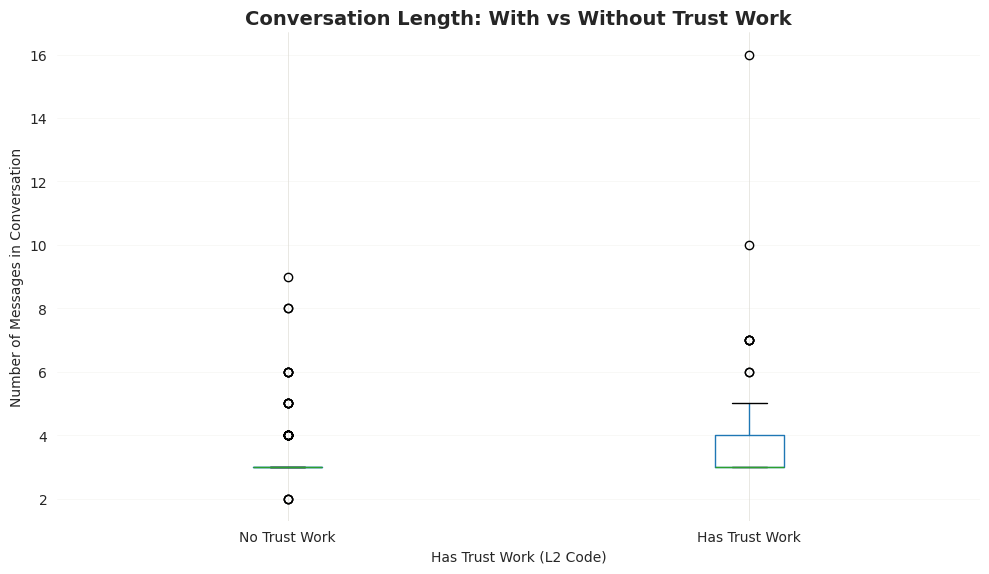


T-test: t=-1.408, p=0.1606
✗ No significant difference in conversation length

💡 KEY QUESTION: Does trust work generate longer or shorter exchanges?


In [ ]:
# Compare conversations WITH vs WITHOUT trust work
print("="*60)
print("CONVERSATIONS WITH vs WITHOUT TRUST WORK (L2)")
print("="*60)

conv_with_codes['has_L2'] = conv_with_codes['L2_code'].notna()

length_by_l2_presence = conv_with_codes.groupby('has_L2')['length'].agg([
    ('Count', 'count'),
    ('Mean Length', 'mean'),
    ('Median Length', 'median'),
    ('Std', 'std')
]).round(1)

length_by_l2_presence.index = ['No Trust Work', 'Has Trust Work']

print("\n", length_by_l2_presence)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
conv_with_codes.boxplot(column='length', by='has_L2', ax=ax)
plt.suptitle('')
plt.title('Conversation Length: With vs Without Trust Work', fontsize=14, fontweight='bold')
plt.xlabel('Has Trust Work (L2 Code)')
plt.ylabel('Number of Messages in Conversation')
ax.set_xticklabels(['No Trust Work', 'Has Trust Work'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical test
no_l2_lengths = conv_with_codes[~conv_with_codes['has_L2']]['length']
has_l2_lengths = conv_with_codes[conv_with_codes['has_L2']]['length']

t_stat, p_val = stats.ttest_ind(no_l2_lengths, has_l2_lengths)

print(f"\nT-test: t={t_stat:.3f}, p={p_val:.4f}")
if p_val < 0.05:
    print("✓ Significant difference in conversation length")
else:
    print("✗ No significant difference in conversation length")

print("\n💡 KEY QUESTION: Does trust work generate longer or shorter exchanges?")

In [ ]:
# Calculate Cohen's d (effect size for t-test)
print("\n" + "="*60)
print("EFFECT SIZE: Cohen's d")
print("="*60)

# Calculate means and pooled standard deviation
mean_no_l2 = no_l2_lengths.mean()
mean_has_l2 = has_l2_lengths.mean()
mean_diff = mean_has_l2 - mean_no_l2

# Pooled standard deviation
n1 = len(no_l2_lengths)
n2 = len(has_l2_lengths)
pooled_std = np.sqrt(((n1-1)*no_l2_lengths.std()**2 + (n2-1)*has_l2_lengths.std()**2) / (n1 + n2 - 2))

cohens_d = mean_diff / pooled_std

print(f"\nMean conversation length (no L2): {mean_no_l2:.2f} messages")
print(f"Mean conversation length (with L2): {mean_has_l2:.2f} messages")
print(f"Difference: {mean_diff:.2f} messages")
print(f"\nCohen's d: {cohens_d:.3f}")

# Interpretation
if abs(cohens_d) < 0.2:
    strength = "negligible"
    color = "⚪"
elif abs(cohens_d) < 0.5:
    strength = "small"
    color = "🟡"
elif abs(cohens_d) < 0.8:
    strength = "medium"
    color = "🟠"
else:
    strength = "large"
    color = "🔴"

print(f"Effect size: {strength} {color}")

# Direction
if cohens_d > 0:
    direction = "Conversations WITH trust work are longer"
elif cohens_d < 0:
    direction = "Conversations WITHOUT trust work are longer"
else:
    direction = "No difference"

print(f"Direction: {direction}")

print("\n💡 INTERPRETATION:")
print("Cohen's d measures the standardized difference between two groups.")
print("  |d| < 0.2  = negligible effect")
print("  |d| = 0.2-0.5  = small effect")
print("  |d| = 0.5-0.8  = medium effect")
print("  |d| > 0.8  = large effect")

print("\n📝 FOR YOUR PAPER:")
if p_val < 0.05:
    print(f"\"Conversations containing trust work (M = {mean_has_l2:.1f}, SD = {has_l2_lengths.std():.1f})")
    print(f"were significantly {'longer' if cohens_d > 0 else 'shorter'} than conversations without trust work")
    print(f"(M = {mean_no_l2:.1f}, SD = {no_l2_lengths.std():.1f}), t({n1+n2-2}) = {t_stat:.2f},")
    print(f"p = {p_val:.3f}, d = {cohens_d:.2f}, a {strength} effect.\"")
else:
    print(f"\"No significant difference in conversation length was found between")
    print(f"conversations with (M = {mean_has_l2:.1f}) and without (M = {mean_no_l2:.1f}) trust work,")
    print(f"t({n1+n2-2}) = {t_stat:.2f}, p = {p_val:.3f}, d = {cohens_d:.2f}.\"")


EFFECT SIZE: Cohen's d

Mean conversation length (no L2): 3.47 messages
Mean conversation length (with L2): 3.77 messages
Difference: 0.30 messages

Cohen's d: 0.201
Effect size: small 🟡
Direction: Conversations WITH trust work are longer

💡 INTERPRETATION:
Cohen's d measures the standardized difference between two groups.
  |d| < 0.2  = negligible effect
  |d| = 0.2-0.5  = small effect
  |d| = 0.5-0.8  = medium effect
  |d| > 0.8  = large effect

📝 FOR YOUR PAPER:
"No significant difference in conversation length was found between
conversations with (M = 3.8) and without (M = 3.5) trust work,
t(198) = -1.41, p = 0.161, d = 0.20."


In [ ]:
# Create a summary table of all statistical tests
print("="*60)
print("SUMMARY: ALL STATISTICAL TESTS")
print("="*60)

statistical_summary = pd.DataFrame({
    'Test': [
        'Chi-square (L1 × L2 association)',
        'Cramér\'s V (effect size)',
        'T-test (conversation length)',
        'Cohen\'s d (effect size)'
    ],
    'Statistic': [
        f"χ²({dof}) = {chi2:.2f}",
        f"V = {cramers_v:.3f}",
        f"t({n1+n2-2}) = {t_stat:.2f}",
        f"d = {cohens_d:.3f}"
    ],
    'p-value': [
        f"< .001" if p_value < 0.001 else f"{p_value:.4f}",
        "N/A (descriptive)",
        f"= {p_val:.4f}" if p_val >= 0.001 else "< .001",
        "N/A (descriptive)"
    ],
    'Interpretation': [
        "Significant association",
        f"{strength.capitalize()} effect",
        "Significant" if p_val < 0.05 else "Not significant",
        f"{strength.capitalize()} effect"
    ]
})

print("\n")
print(statistical_summary.to_string(index=False))

print("\n" + "="*60)
print("KEY TAKEAWAYS FOR YOUR FINDINGS:")
print("="*60)
print(f"✓ Trust behaviors are NOT randomly distributed (p < .001)")
print(f"✓ The L1×L2 association strength is {strength}")
print(f"✓ Conversation length {'differs' if p_val < 0.05 else 'does not differ'} by trust work presence")
if p_val < 0.05:
    print(f"✓ This difference is {'meaningful' if abs(cohens_d) >= 0.5 else 'small but detectable'}")

SUMMARY: ALL STATISTICAL TESTS


                            Test        Statistic           p-value          Interpretation
Chi-square (L1 × L2 association) χ²(16) = 1114.66            < .001 Significant association
        Cramér's V (effect size)        V = 0.576 N/A (descriptive)            Small effect
    T-test (conversation length)   t(198) = -1.41          = 0.1606         Not significant
         Cohen's d (effect size)        d = 0.201 N/A (descriptive)            Small effect

KEY TAKEAWAYS FOR YOUR FINDINGS:
✓ Trust behaviors are NOT randomly distributed (p < .001)
✓ The L1×L2 association strength is small
✓ Conversation length does not differ by trust work presence


In [ ]:
# ============================================================
# THREAD GENERATION RATE BY L1 COMMUNICATIVE FUNCTION
# ============================================================
print("=" * 60)
print("THREAD GENERATION RATE BY L1 CODE")
print("=" * 60)

# --- 1. Base rate: L1 distribution in full coded comment sample ---
l1_comment_counts = (
    comments_clean['L1_code']
    .value_counts()
    .rename('n_comments')
)
l1_comment_pct = (l1_comment_counts / l1_comment_counts.sum() * 100).rename('pct_comments')

# --- 2. Root message: first message per thread by timestamp ---
roots = (
    conversations_clean
    .sort_values('comment_timestamp')
    .groupby('conversation_id', sort=False)
    .first()
    .reset_index()
)
n_roots = len(roots)  # 200

l1_root_counts = (
    roots['L1_code']
    .value_counts()
    .rename('n_roots')
)
l1_root_pct = (l1_root_counts / n_roots * 100).rename('pct_roots')

# --- 3. Assemble and compute thread generation rate ---
tgr = pd.concat([l1_comment_counts, l1_comment_pct, l1_root_counts, l1_root_pct], axis=1).fillna(0)
tgr['thread_gen_rate'] = (tgr['pct_roots'] / tgr['pct_comments']).round(3)

# Strip L1_ prefix for display
tgr.index = tgr.index.str.replace('L1_', '', regex=False)
tgr = tgr.sort_values('thread_gen_rate', ascending=False)

tgr_display = tgr.rename(columns={
    'n_comments':      'n (comments)',
    'pct_comments':    '% of Comments',
    'n_roots':         'n (roots)',
    'pct_roots':       '% of Thread Roots',
    'thread_gen_rate': 'Thread Generation Rate'
})

print(f"\nBase: {l1_comment_counts.sum():,} coded comments | {n_roots} conversation roots\n")
print(tgr_display.round(2).to_string())

print("\n" + "-" * 60)
print("INTERPRETATION:")
print("  Rate > 1.0 → over-represented as thread starters")
print("  Rate < 1.0 → under-represented as thread starters")
print("  Rate = 1.0 → initiates threads at its base-rate frequency")
print("-" * 60)
print("\n💡 NOTE FOR WRITE-UP:")
print("  Thread generation rate is a descriptive ratio, not a test statistic.")
print("  Pair with chi-square (observed vs. expected roots) for inferential claim.")

THREAD GENERATION RATE BY L1 CODE

Base: 1,978 coded comments | 200 conversation roots

               n (comments)  % of Comments  n (roots)  % of Thread Roots  Thread Generation Rate
L1_code                                                                                         
operational              50           2.53       23.0               11.5                    4.55
understanding           510          25.78       70.0               35.0                    1.36
social                  845          42.72       89.0               44.5                    1.04
informational           440          22.24       18.0                9.0                    0.40
emotional               133           6.72        0.0                0.0                    0.00

------------------------------------------------------------
INTERPRETATION:
  Rate > 1.0 → over-represented as thread starters
  Rate < 1.0 → under-represented as thread starters
  Rate = 1.0 → initiates threads at its base-rate fr

REPLY PROBABILITY BY L1 CODE

                total  n_roots  reply_probability
L1_code                                         
social           845       65             0.0769
informational    440       26             0.0591
emotional        133        6             0.0451
understanding    510        2             0.0039
operational       50        0             0.0000


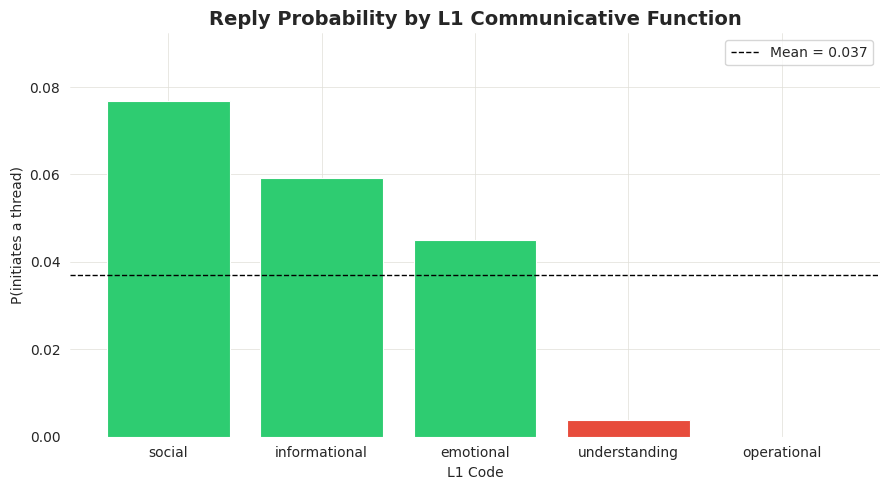


💡 Interpretation: P(reply) = fraction of all messages of each L1 type
   that appear as conversation roots in the coded comment sample.


In [ ]:
# ============================================================
# PROMPT 2: REPLY PROBABILITY BY L1 TYPE
# ============================================================
# P(reply) = proportion of messages of each L1 type that appear
# as conversation roots (conversation_sequence == 1)
# Denominator = all coded comments of that L1 type

print("=" * 60)
print("REPLY PROBABILITY BY L1 CODE")
print("=" * 60)

# Root = first message in a thread (sequence == 1 and in a conversation)
comments_clean['is_root'] = (
    comments_clean['conversation_id'].notna() &
    (comments_clean['conversation_sequence'] == 1)
)

reply_prob = (
    comments_clean
    .groupby('L1_code')
    .agg(
        total    = ('L1_code', 'count'),
        n_roots  = ('is_root', 'sum')
    )
)
reply_prob['reply_probability'] = (reply_prob['n_roots'] / reply_prob['total']).round(4)
reply_prob = reply_prob.sort_values('reply_probability', ascending=False)
reply_prob.index = reply_prob.index.str.replace('L1_', '', regex=False)

print("\n", reply_prob.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if v > reply_prob['reply_probability'].mean() else '#e74c3c'
          for v in reply_prob['reply_probability']]
ax.bar(reply_prob.index, reply_prob['reply_probability'], color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(reply_prob['reply_probability'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Mean = {reply_prob['reply_probability'].mean():.3f}")
ax.set_title('Reply Probability by L1 Communicative Function', fontsize=14, fontweight='bold')
ax.set_xlabel('L1 Code')
ax.set_ylabel('P(initiates a thread)')
ax.legend()
ax.set_ylim(0, reply_prob['reply_probability'].max() * 1.2)
plt.tight_layout()
plt.show()

print("\n💡 Interpretation: P(reply) = fraction of all messages of each L1 type")
print("   that appear as conversation roots in the coded comment sample.")

L1 DISTRIBUTION: FULL COMMENTS vs CONVERSATION ROOTS


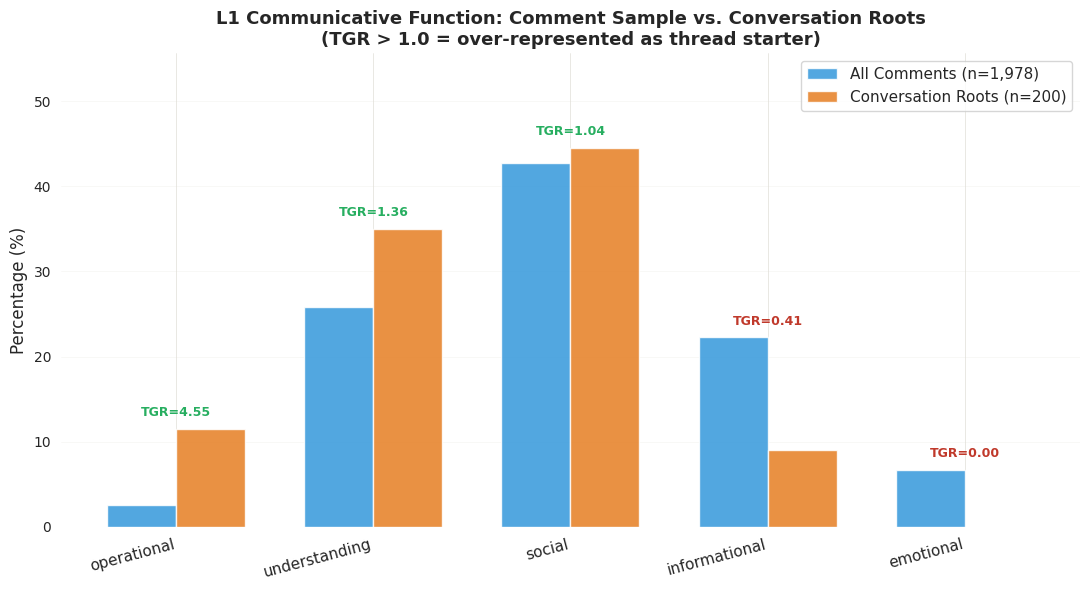


Table for paper:
               % of Comments  % of Thread Roots  Thread Generation Rate
L1_code                                                                
operational             2.53               11.5                    4.55
understanding          25.78               35.0                    1.36
social                 42.72               44.5                    1.04
informational          22.24                9.0                    0.40
emotional               6.72                0.0                    0.00


In [ ]:
# ============================================================
# PROMPT 3: VISUAL COMPARISON — COMMENTS vs CONVERSATION ROOTS
# ============================================================

print("=" * 60)
print("L1 DISTRIBUTION: FULL COMMENTS vs CONVERSATION ROOTS")
print("=" * 60)

# Re-derive for clarity (safe to re-run; uses tgr built in Prompt 1 cell)
plot_data = tgr_display[['% of Comments', '% of Thread Roots']].copy()

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(plot_data))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], plot_data['% of Comments'],
               width, label='All Comments (n=1,978)', color='#3498db', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], plot_data['% of Thread Roots'],
               width, label='Conversation Roots (n=200)', color='#e67e22', alpha=0.85)

# Annotate with TGR above each pair
for i, (label, row) in enumerate(tgr_display.iterrows()):
    tgr_val = row['Thread Generation Rate']
    color = '#27ae60' if tgr_val >= 1.0 else '#c0392b'
    ax.text(i, max(row['% of Comments'], row['% of Thread Roots']) + 1.5,
            f"TGR={tgr_val:.2f}", ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(plot_data.index, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('L1 Communicative Function: Comment Sample vs. Conversation Roots\n'
             '(TGR > 1.0 = over-represented as thread starter)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(plot_data.max()) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTable for paper:")
print(tgr_display[['% of Comments', '% of Thread Roots', 'Thread Generation Rate']].round(2).to_string())

CREATOR-LEVEL CODE DISTRIBUTION: RYAN vs. MAX

--- L1 COMMUNICATIVE FUNCTION BY CREATOR ---

L1_code  n (comments)  emotional  informational  operational  social  understanding
creator                                                                            
Max               879        9.1           22.5          1.9    40.0           26.4
Ryan              857        4.8           21.7          2.8    42.5           28.2

Chi-square (L1 × creator): χ²(4) = 14.28, p = 0.0065, Cramér's V = 0.091

--- L2 TRUST BEHAVIOR BY CREATOR (% of L2-coded comments per creator) ---

NOTE: Denominator = L2-coded comments only (not all comments)

L2_code  n (L2-coded)  creator_question  ground_truth  highlighting  repair  vouching
creator                                                                              
Max               370              55.4          27.3          10.5     2.2       4.6
Ryan              395              56.7          29.9           5.8     4.6       3.0

Chi-square (L

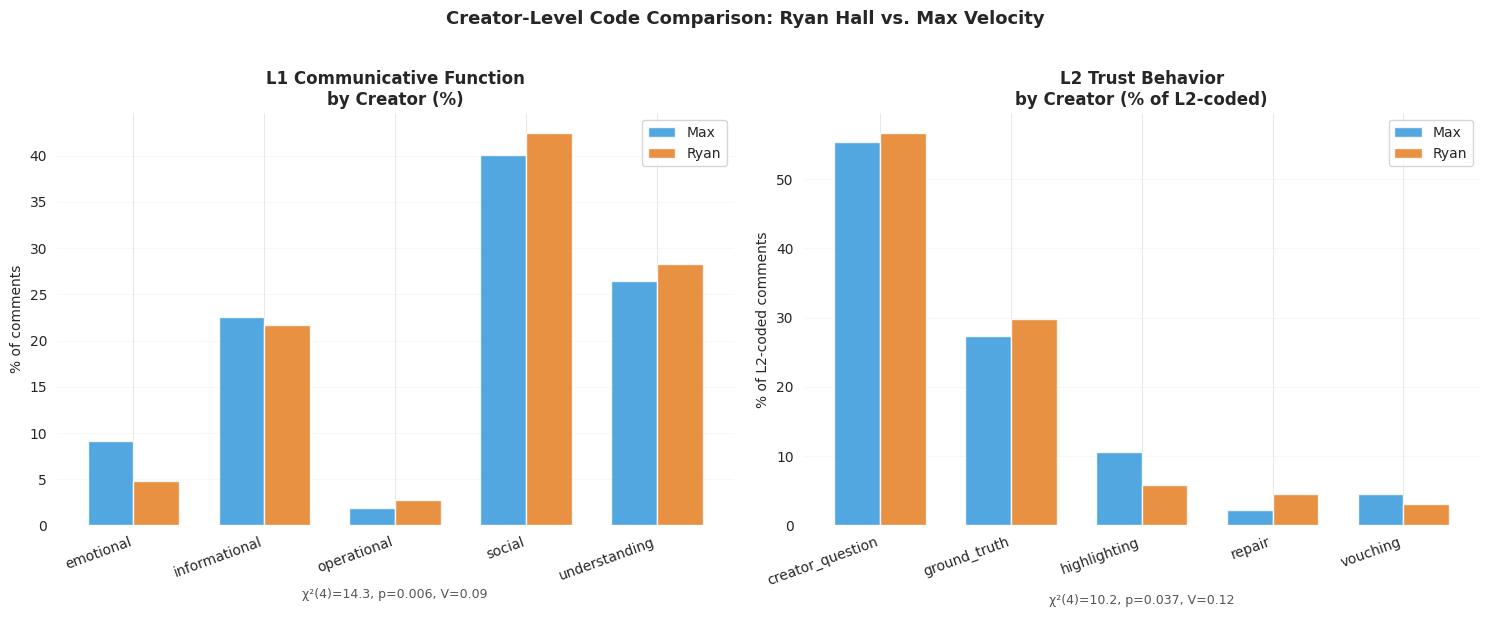


💡 WRITE-UP NOTE:
  L2 percentages use L2-coded comments as denominator (per §8.5.6 spec),
  not all comments — this reflects pathway composition within trust work,
  not overall trust-behavior rate.


In [ ]:
# ============================================================
# CREATOR-LEVEL L1 AND L2 CODE COMPARISON (Ryan vs. Max)
# ============================================================
# Per dissertation §8.5.6: focus on Ryan and Max (TWC n too small
# for meaningful distributional comparison at this level)

print("=" * 60)
print("CREATOR-LEVEL CODE DISTRIBUTION: RYAN vs. MAX")
print("=" * 60)

focal_creators = ['ryan', 'max']
creator_df = comments_clean[comments_clean['creator'].isin(focal_creators)].copy()

# ── L1 Distribution ──────────────────────────────────────────
print("\n--- L1 COMMUNICATIVE FUNCTION BY CREATOR ---\n")

l1_by_creator = (
    creator_df
    .groupby(['creator', 'L1_code'])
    .size()
    .unstack(fill_value=0)
)
l1_by_creator_pct = l1_by_creator.div(l1_by_creator.sum(axis=1), axis=0) * 100
l1_by_creator_pct.columns = l1_by_creator_pct.columns.str.replace('L1_', '', regex=False)
l1_by_creator_pct.index = l1_by_creator_pct.index.str.capitalize()

# Add raw n per creator
l1_by_creator_pct.insert(0, 'n (comments)', l1_by_creator.sum(axis=1).values)

print(l1_by_creator_pct.round(1).to_string())

# Chi-square test on L1 × creator
from scipy.stats import chi2_contingency
l1_contingency = l1_by_creator.loc[focal_creators]
chi2_l1, p_l1, dof_l1, _ = chi2_contingency(l1_contingency)
n_l1 = l1_contingency.values.sum()
cramers_v_l1 = np.sqrt(chi2_l1 / (n_l1 * (min(l1_contingency.shape) - 1)))
print(f"\nChi-square (L1 × creator): χ²({dof_l1}) = {chi2_l1:.2f}, p = {p_l1:.4f}, Cramér's V = {cramers_v_l1:.3f}")

# ── L2 Distribution (among L2-coded comments only) ───────────
print("\n--- L2 TRUST BEHAVIOR BY CREATOR (% of L2-coded comments per creator) ---\n")
print("NOTE: Denominator = L2-coded comments only (not all comments)\n")

l2_df = creator_df[creator_df['L2_code'].notna()].copy()

l2_by_creator = (
    l2_df
    .groupby(['creator', 'L2_code'])
    .size()
    .unstack(fill_value=0)
)
l2_by_creator_pct = l2_by_creator.div(l2_by_creator.sum(axis=1), axis=0) * 100
l2_by_creator_pct.columns = l2_by_creator_pct.columns.str.replace('L2_', '', regex=False)
l2_by_creator_pct.index = l2_by_creator_pct.index.str.capitalize()

# Add raw n of L2-coded comments per creator
l2_by_creator_pct.insert(0, 'n (L2-coded)', l2_by_creator.sum(axis=1).values)

print(l2_by_creator_pct.round(1).to_string())

# Chi-square test on L2 × creator
l2_contingency = l2_by_creator.loc[focal_creators]
chi2_l2, p_l2, dof_l2, _ = chi2_contingency(l2_contingency)
n_l2 = l2_contingency.values.sum()
cramers_v_l2 = np.sqrt(chi2_l2 / (n_l2 * (min(l2_contingency.shape) - 1)))
print(f"\nChi-square (L2 × creator): χ²({dof_l2}) = {chi2_l2:.2f}, p = {p_l2:.4f}, Cramér's V = {cramers_v_l2:.3f}")

# ── Combined figure ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = {'Ryan': '#3498db', 'Max': '#e67e22'}

# L1 panel
l1_plot = l1_by_creator_pct.drop(columns='n (comments)')
x = np.arange(len(l1_plot.columns))
width = 0.35
for i, (creator, row) in enumerate(l1_plot.iterrows()):
    offset = (i - 0.5) * width
    axes[0].bar(x + offset, row.values, width, label=creator,
                color=list(colors.values())[i], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(l1_plot.columns, rotation=20, ha='right')
axes[0].set_title('L1 Communicative Function\nby Creator (%)', fontweight='bold')
axes[0].set_ylabel('% of comments')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
sig_label = f"χ²({dof_l1})={chi2_l1:.1f}, p={'<.001' if p_l1 < .001 else f'{p_l1:.3f}'}, V={cramers_v_l1:.2f}"
axes[0].set_xlabel(sig_label, fontsize=9, color='#555')

# L2 panel
l2_plot = l2_by_creator_pct.drop(columns='n (L2-coded)')
x2 = np.arange(len(l2_plot.columns))
for i, (creator, row) in enumerate(l2_plot.iterrows()):
    offset = (i - 0.5) * width
    axes[1].bar(x2 + offset, row.values, width, label=creator,
                color=list(colors.values())[i], alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(l2_plot.columns, rotation=20, ha='right')
axes[1].set_title('L2 Trust Behavior\nby Creator (% of L2-coded)', fontweight='bold')
axes[1].set_ylabel('% of L2-coded comments')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
sig_label2 = f"χ²({dof_l2})={chi2_l2:.1f}, p={'<.001' if p_l2 < .001 else f'{p_l2:.3f}'}, V={cramers_v_l2:.2f}"
axes[1].set_xlabel(sig_label2, fontsize=9, color='#555')

plt.suptitle('Creator-Level Code Comparison: Ryan Hall vs. Max Velocity',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 WRITE-UP NOTE:")
print("  L2 percentages use L2-coded comments as denominator (per §8.5.6 spec),")
print("  not all comments — this reflects pathway composition within trust work,")
print("  not overall trust-behavior rate.")

TRUST CONFIGURATION WITHIN SENSEMAKING ORIENTATIONS
BY CREATOR

--- FLAT TABLE FOR WRITE-UP ---

                                   Max  Ryan  Overall  n (Max)  n (Ryan)
Informational → Ground Truth      45.5  58.6     51.6    198.0     186.0
Social → Vouching                  4.5   3.0      3.4    352.0     364.0
Understanding → Creator Question  85.8  90.9     88.2    232.0     242.0


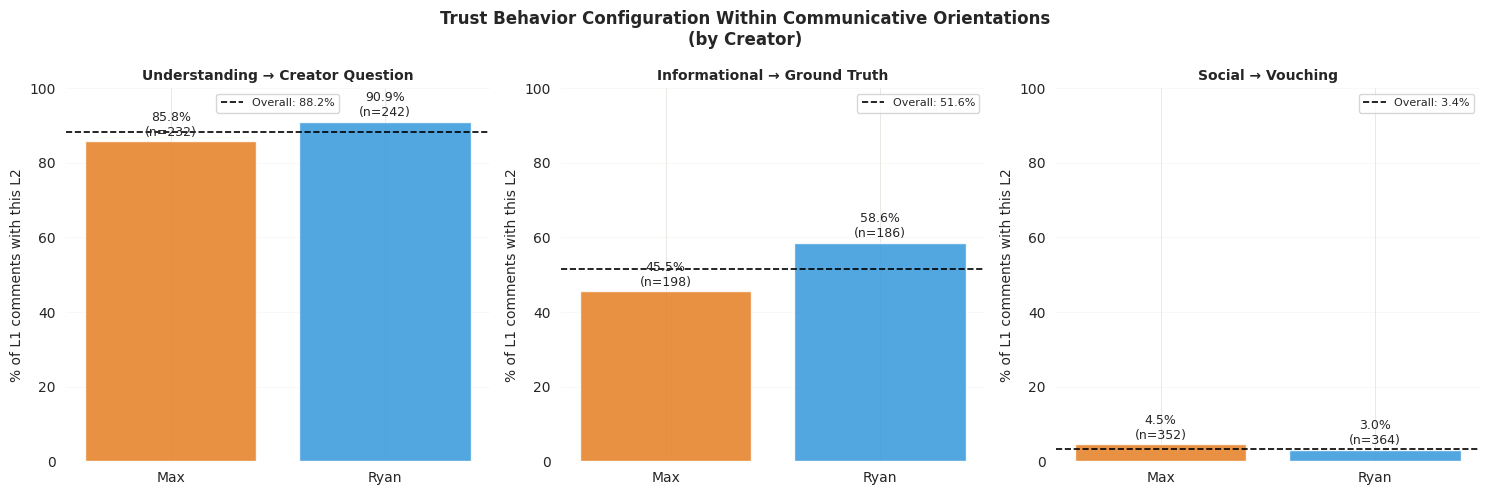


💡 WRITE-UP NOTE:
  These % use all comments of that L1 type as denominator (not just L2-coded).
  They answer: of all understanding-seeking comments in Max's chat,
  what fraction directed a question to the creator?


In [ ]:
# ============================================================
# WITHIN-ORIENTATION TRUST CONFIGURATION BY CREATOR
# ============================================================
# For each creator: of L1_understanding comments, what % include
# L2_creator_question? Of L1_informational, % with L2_ground_truth?
# Of L1_social, % with L2_vouching?
# Denominator = all comments of that L1 type for that creator.

print("=" * 60)
print("TRUST CONFIGURATION WITHIN SENSEMAKING ORIENTATIONS")
print("BY CREATOR")
print("=" * 60)

focal = comments_clean[comments_clean['creator'].isin(['ryan', 'max'])].copy()

# Define the three focal pairings from §8.5.6
pairings = [
    ('L1_understanding', 'L2_creator_question', 'Understanding → Creator Question'),
    ('L1_informational', 'L2_ground_truth',     'Informational → Ground Truth'),
    ('L1_social',        'L2_vouching',          'Social → Vouching'),
]

rows = []
for l1, l2, label in pairings:
    for creator in ['max', 'ryan']:
        subset = focal[focal['creator'] == creator]
        l1_comments = subset[subset['L1_code'] == l1]
        n_l1 = len(l1_comments)
        n_paired = (l1_comments['L2_code'] == l2).sum()
        pct = (n_paired / n_l1 * 100) if n_l1 > 0 else 0
        rows.append({
            'Pairing': label,
            'Creator': creator.capitalize(),
            'n (L1 type)': n_l1,
            'n (with L2)': n_paired,
            '% paired': round(pct, 1)
        })

config_df = pd.DataFrame(rows)

# Pivot for clean display
config_pivot = config_df.pivot_table(
    index='Pairing',
    columns='Creator',
    values=['n (L1 type)', 'n (with L2)', '% paired'],
    aggfunc='first'
)

# Flat display table
print("\n--- FLAT TABLE FOR WRITE-UP ---\n")
flat = config_df.pivot_table(
    index='Pairing',
    columns='Creator',
    values='% paired',
    aggfunc='first'
).round(1)
flat.columns.name = None
flat.index.name = None

# Add aggregate column (both creators combined)
for l1, l2, label in pairings:
    l1_all = comments_clean[comments_clean['L1_code'] == l1]
    n_all = len(l1_all)
    n_paired_all = (l1_all['L2_code'] == l2).sum()
    flat.loc[label, 'Overall'] = round(n_paired_all / n_all * 100, 1) if n_all > 0 else 0

# Add n denominators
for l1, l2, label in pairings:
    for creator in ['max', 'ryan']:
        subset = focal[focal['creator'] == creator]
        flat.loc[label, f'n ({creator.capitalize()})'] = len(subset[subset['L1_code'] == l1])

print(flat.to_string())

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'Max': '#e67e22', 'Ryan': '#3498db'}

for ax, (l1, l2, label) in zip(axes, pairings):
    creator_data = config_df[config_df['Pairing'] == label].set_index('Creator')
    bars = ax.bar(creator_data.index,
                  creator_data['% paired'],
                  color=[colors[c] for c in creator_data.index],
                  alpha=0.85, edgecolor='white')
    # Add overall average line
    overall_pct = flat.loc[label, 'Overall']
    ax.axhline(overall_pct, color='black', linestyle='--', linewidth=1.2,
               label=f'Overall: {overall_pct:.1f}%')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_ylabel('% of L1 comments with this L2')
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, (_, row) in zip(bars, creator_data.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f"{row['% paired']:.1f}%\n(n={int(row['n (L1 type)'])})",
                ha='center', fontsize=9)

plt.suptitle('Trust Behavior Configuration Within Communicative Orientations\n(by Creator)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 WRITE-UP NOTE:")
print("  These % use all comments of that L1 type as denominator (not just L2-coded).")
print("  They answer: of all understanding-seeking comments in Max's chat,")
print("  what fraction directed a question to the creator?")

In [ ]:
# ============================================================
# REPAIR ECOLOGY: EXCERPTS BY CREATOR
# ============================================================
# Pulls all L2_repair comments from comments_clean, split by
# creator, for qualitative illustration in §8.5.6

print("=" * 60)
print("REPAIR EXCERPTS BY CREATOR")
print("=" * 60)

repair_comments = comments_clean[
    (comments_clean['L2_code'] == 'L2_repair') &
    (comments_clean['creator'].isin(['ryan', 'max']))
].copy()

print(f"\nTotal repair comments (Ryan + Max): {len(repair_comments)}")
print(f"Max Velocity: {(repair_comments['creator'] == 'max').sum()}")
print(f"Ryan Hall:    {(repair_comments['creator'] == 'ryan').sum()}")

for creator in ['max', 'ryan']:
    label = 'Max Velocity' if creator == 'max' else 'Ryan Hall'
    subset = repair_comments[repair_comments['creator'] == creator].reset_index(drop=True)
    print(f"\n{'='*50}")
    print(f"{label.upper()} — all repair comments (n={len(subset)})")
    print(f"{'='*50}")
    for i, row in subset.iterrows():
        print(f"\n  [{row.get('coding_id', i)}] \"{row['comment_text']}\"")
        if 'L1_code' in row:
            print(f"         L1: {row['L1_code']}")

REPAIR EXCERPTS BY CREATOR

Total repair comments (Ryan + Max): 26
Max Velocity: 8
Ryan Hall:    18

MAX VELOCITY — all repair comments (n=8)

  [12] "Max it’s pronounced Cape Jerardeau"
         L1: L1_informational

  [351] "You’re gettin closer with Cape Girardeau"
         L1: L1_social

  [388] "it's ACK-ron , Ohio. lol"
         L1: L1_informational

  [457] "@Julia-543 is it pronounced Cher-o-kee or Cher-I-o-kee? I failed English 10 years in a row :grinning_face_with_sweat: just a little confused!'"
         L1: L1_informational

  [462] "law enforcement watching Max's stream and reported it cause max made a mistake"
         L1: L1_informational

  [530] "Can you mention states as some have similar or exact city/county names"
         L1: L1_operational

  [531] "@Tyler Rufener discreet cells are ones not in a line of thunderstorms. They're off by themselves.'"
         L1: L1_informational

  [745] "@Freedom Revolution Network NWS made it very clear that their preliminary was 

---
## Qualitative Example Extraction

**From atoms to organisms: Pulling illustrative examples**

These functions help you extract actual comment text to illustrate patterns in your writing.

In [ ]:
# Function to get example comments for any L1/L2 combination
def get_examples(df, l1_code=None, l2_code=None, n=5, min_words=5, max_words=50):
    """
    Get example comments for specific code combinations

    Parameters:
    - df: DataFrame (comments_clean or conversations_clean)
    - l1_code: L1 code to filter by (or None for all)
    - l2_code: L2 code to filter by (or None for all)
    - n: number of examples to return
    - min_words: minimum word count
    - max_words: maximum word count
    """
    filtered = df.copy()

    # Apply filters
    if l1_code:
        filtered = filtered[filtered['L1_code'] == l1_code]
    if l2_code:
        filtered = filtered[filtered['L2_code'] == l2_code]

    # Filter by word count if available
    if 'word_count' in filtered.columns:
        filtered = filtered[
            (filtered['word_count'] >= min_words) &
            (filtered['word_count'] <= max_words)
        ]

    # Sample randomly
    if len(filtered) > n:
        examples = filtered.sample(n=n, random_state=42)
    else:
        examples = filtered

    return examples

# Test the function
print("="*60)
print("EXAMPLE FUNCTION TEST")
print("="*60)
print("\nGetting 3 examples of L1_understanding + L2_creator_question:\n")

examples = get_examples(comments_clean,
                        l1_code='L1_understanding',
                        l2_code='L2_creator_question',
                        n=3)

for idx, row in examples.iterrows():
    print(f"Example {idx}:")
    print(f"  Text: {row['comment_text']}")
    if 'word_count' in row:
        print(f"  Words: {row['word_count']}")
    print()

EXAMPLE FUNCTION TEST

Getting 3 examples of L1_understanding + L2_creator_question:

Example 180:
  Text: Max, how is Alpharetta, GA?
  Words: 5

Example 936:
  Text: hows it looking for O'Fallon MO?
  Words: 6

Example 1391:
  Text: Leelanau County here, what are the chances the sky will give me some ice for my mojito?
  Words: 17



In [ ]:
# Generate example sets for each L1 × L2 combination
print("="*60)
print("EXTRACTING EXAMPLES FOR ALL L1 × L2 COMBINATIONS")
print("="*60)

# Get all L1 and L2 codes
l1_codes = comments_clean['L1_code'].unique()
l2_codes = comments_clean['L2_code'].dropna().unique()

# Create example library
example_library = {}

for l1 in l1_codes:
    for l2 in l2_codes:
        examples = get_examples(comments_clean, l1_code=l1, l2_code=l2, n=3)

        if len(examples) > 0:
            key = f"{l1} × {l2}"
            example_library[key] = examples

            print(f"\n{key}: {len(examples)} examples found")
            for idx, row in examples.iterrows():
                print(f"  - {row['comment_text'][:100]}..." if len(row['comment_text']) > 100
                      else f"  - {row['comment_text']}")

print(f"\n✓ Total unique L1 × L2 combinations with examples: {len(example_library)}")

EXTRACTING EXAMPLES FOR ALL L1 × L2 COMBINATIONS

L1_social × L2_creator_question: 3 examples found
  - What’s the status of graduation???!!! Suma cum lade?
  - MAX !!!! what are you taking in SCHOOL??
  - Is Reilly your buddy from your classes?

L1_social × L2_highlighting: 3 examples found
  - That is a spaceship - yowzers!
  - sick looking cloud in Bowling Green
  - the Strom in round rock is falling apart

L1_social × L2_ground_truth: 3 examples found
  - @EastTXMaggie It sounds like it is going to be rough later.'
  - @Jenny Arellano it will probably be longer'
  - They park under the overpasses to save their paint from hail.

L1_social × L2_repair: 3 examples found
  - You’re gettin closer with Cape Girardeau
  - @Trouble it's actually imperative a town is at least closely named. I've lost a friend's family beca...
  - folks around there do pronounce Advance as ADD-vance. it's a southern thing I guess. lol

L1_social × L2_vouching: 3 examples found
  - I've been following David f

In [ ]:
# Function to display full conversation threads
def get_conversation(conv_id, df=conversations_clean):
    """
    Display a full conversation thread
    """
    conv = df[df['conversation_id'] == conv_id].sort_values('comment_timestamp')

    print(f"\nConversation ID: {conv_id}")
    print(f"L1: {conv['L1_code'].iloc[0]}")
    print(f"L2: {conv['L2_code'].iloc[0] if pd.notna(conv['L2_code'].iloc[0]) else 'None'}")
    print(f"Length: {len(conv)} messages")
    print("="*60)

    for idx, row in conv.iterrows():
        timestamp = row['comment_timestamp'] if 'comment_timestamp' in row else 'N/A'
        print(f"\n[{timestamp}]")
        print(f"{row['comment_text']}")

    print("\n" + "="*60)
    return conv

# Example usage: Show a random conversation
print("="*60)
print("EXAMPLE CONVERSATION THREAD")
print("="*60)

random_conv_id = conversations_clean['conversation_id'].sample(1, random_state=42).iloc[0]
example_conv = get_conversation(random_conv_id)

EXAMPLE CONVERSATION THREAD

Conversation ID: 834
L1: L1_operational
L2: None
Length: 6 messages

[4/6/25 0:41]
:red_exclamation_mark:PDS = Particularly Dangerous Situation :red_exclamation_mark:

[4/6/25 0:42]
Hi @Julia-543 gtsy

[4/6/25 0:47]
@Julia-543 yes for now but no timeouts unless they keep doing it. We need the chat focused on the situation at hand.

[4/6/25 0:48]
@Julia-543 oops

[4/6/25 0:48]
@Julia-543 we really want the chat to be open to those who are in danger to ask questions & such & not clutter it up with nonsense.

[4/6/25 0:49]
@Julia-543 You’re welcome hon :hugging_face:



In [ ]:
# Find conversations with specific patterns
def find_conversations_by_pattern(l1_code=None, l2_code=None,
                                   min_length=None, max_length=None,
                                   n=5, df=conversations_clean):
    """
    Find conversations matching specific criteria
    """
    # Get unique conversations with codes
    conv_summary = df.groupby('conversation_id').agg({
        'L1_code': 'first',
        'L2_code': 'first',
        'comment_text': 'size'
    }).rename(columns={'comment_text': 'length'})

    # Apply filters
    filtered = conv_summary.copy()

    if l1_code:
        filtered = filtered[filtered['L1_code'] == l1_code]
    if l2_code:
        filtered = filtered[filtered['L2_code'] == l2_code]
    if min_length:
        filtered = filtered[filtered['length'] >= min_length]
    if max_length:
        filtered = filtered[filtered['length'] <= max_length]

    # Sample
    if len(filtered) > n:
        sampled = filtered.sample(n=n, random_state=42)
    else:
        sampled = filtered

    return sampled.index.tolist()

# Example: Find longer conversations with trust work
print("="*60)
print("FINDING CONVERSATIONS: L2_repair, length >= 3")
print("="*60)

repair_convs = find_conversations_by_pattern(
    l2_code='L2_repair',
    min_length=3,
    n=3
)

print(f"\nFound {len(repair_convs)} conversations matching criteria:")
for conv_id in repair_convs:
    get_conversation(conv_id)

FINDING CONVERSATIONS: L2_repair, length >= 3

Found 3 conversations matching criteria:

Conversation ID: 186
L1: L1_operational
L2: L2_repair
Length: 7 messages

[3/16/25 2:53]
Carrie it isn’t a rule, it’s how much is retained and it depends on the softwarw being used too

[3/16/25 2:53]
@Julia-543 I've always heard it's a YT rule but OK

[3/16/25 2:56]
@Julia-543 you're right :slightly_smiling_face: thank u for clarifying that to me

[3/16/25 2:58]
@Julia-543 :thumbs_up:

[3/16/25 2:59]
@Julia-543 fancy meeting you here

[3/16/25 3:00]
@Julia-543 I hope you & yours are safe

[3/16/25 3:02]
@Julia-543 So far so good, thank God!


Conversation ID: 770
L1: L1_informational
L2: L2_repair
Length: 3 messages

[4/4/25 20:54]
can't believe the Lale City is only an EF3

[4/4/25 20:55]
@Jzilla the rating will change soon, they haven’t finished surveying everything I don’t think

[4/4/25 20:55]
@JZilla Preliminary they haven't surveyed the whole area yet could possibly get upgraded


Conversati

In [ ]:
# Export examples to CSV for easy reference
print("="*60)
print("EXPORTING EXAMPLES TO CSV")
print("="*60)

# Create directory for exports
import os
export_dir = '/content/drive/MyDrive/YOUR_FOLDER_PATH/examples_export/'
os.makedirs(export_dir, exist_ok=True)

# Export examples for each L2 code
for l2 in l2_codes:
    examples = get_examples(comments_clean, l2_code=l2, n=20)

    if len(examples) > 0:
        filename = f"{export_dir}{l2}_examples.csv"
        examples[['comment_text', 'L1_code', 'L2_code', 'word_count']].to_csv(
            filename, index=False
        )
        print(f"✓ Exported {len(examples)} examples for {l2}")

print(f"\n✓ All examples exported to: {export_dir}")

EXPORTING EXAMPLES TO CSV
✓ Exported 20 examples for L2_creator_question
✓ Exported 20 examples for L2_highlighting
✓ Exported 20 examples for L2_ground_truth
✓ Exported 20 examples for L2_repair
✓ Exported 20 examples for L2_vouching

✓ All examples exported to: /content/drive/MyDrive/YOUR_FOLDER_PATH/examples_export/


---
## Optional: Creator & Temporal Analysis

CREATOR COMPARISON - COMMENTS

Sample distribution by creator:
creator
max     879
ryan    857
twc     242
Name: count, dtype: int64

L1 distribution by creator (% within creator):
L1_code  L1_emotional  L1_informational  L1_operational  L1_social  \
creator                                                              
max               9.1              22.5             1.9       40.0   
ryan              4.8              21.7             2.8       42.5   
twc               5.0              23.1             3.7       53.3   

L1_code  L1_understanding  
creator                    
max                  26.4  
ryan                 28.2  
twc                  14.9  


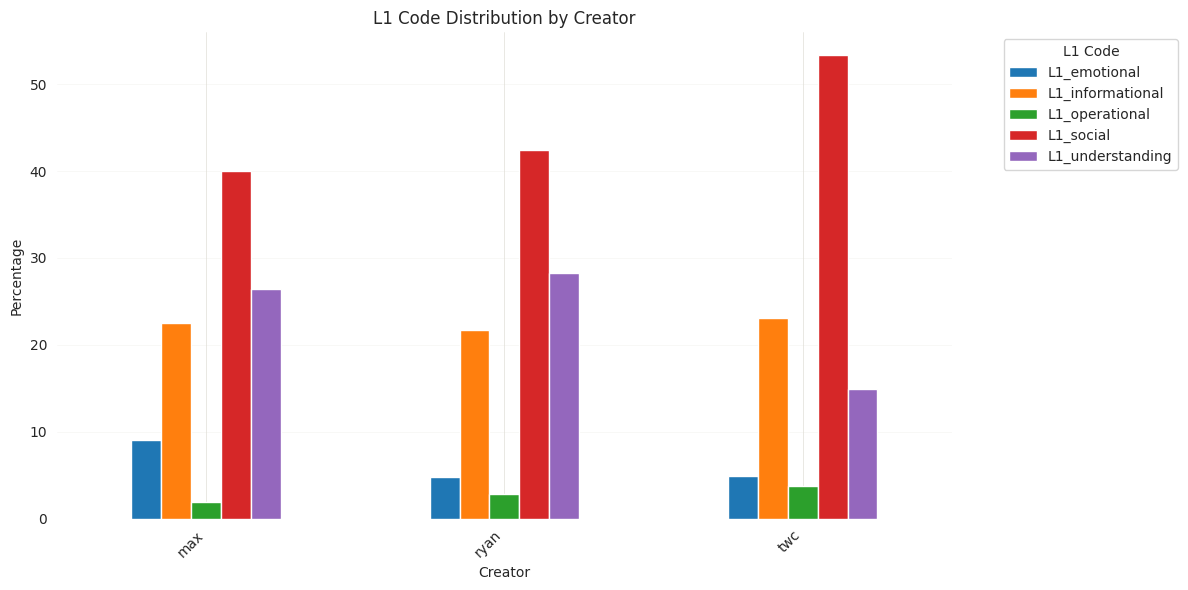


⚠️ Note: Unequal sample sizes may affect interpretation


In [ ]:
# Creator comparison (if interested)
print("="*60)
print("CREATOR COMPARISON - COMMENTS")
print("="*60)

if 'creator' in comments_clean.columns:
    creator_counts = comments_clean['creator'].value_counts()
    print("\nSample distribution by creator:")
    print(creator_counts)

    # L1 by creator
    creator_l1 = pd.crosstab(comments_clean['creator'], comments_clean['L1_code'],
                              normalize='index') * 100

    print("\nL1 distribution by creator (% within creator):")
    print(creator_l1.round(1))

    # Visualize
    creator_l1.plot(kind='bar', figsize=(12, 6), stacked=False)
    plt.title('L1 Code Distribution by Creator')
    plt.ylabel('Percentage')
    plt.xlabel('Creator')
    plt.legend(title='L1 Code', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n⚠️ Note: Unequal sample sizes may affect interpretation")
else:
    print("\n⚠️ 'creator' column not found in comments_clean")

TEMPORAL PATTERNS

L2 (trust work) prevalence by time period:
time_bin
0-30min     42.5
30-60min     NaN
1-2hr        NaN
2-4hr        NaN
4hr+         NaN
dtype: float64


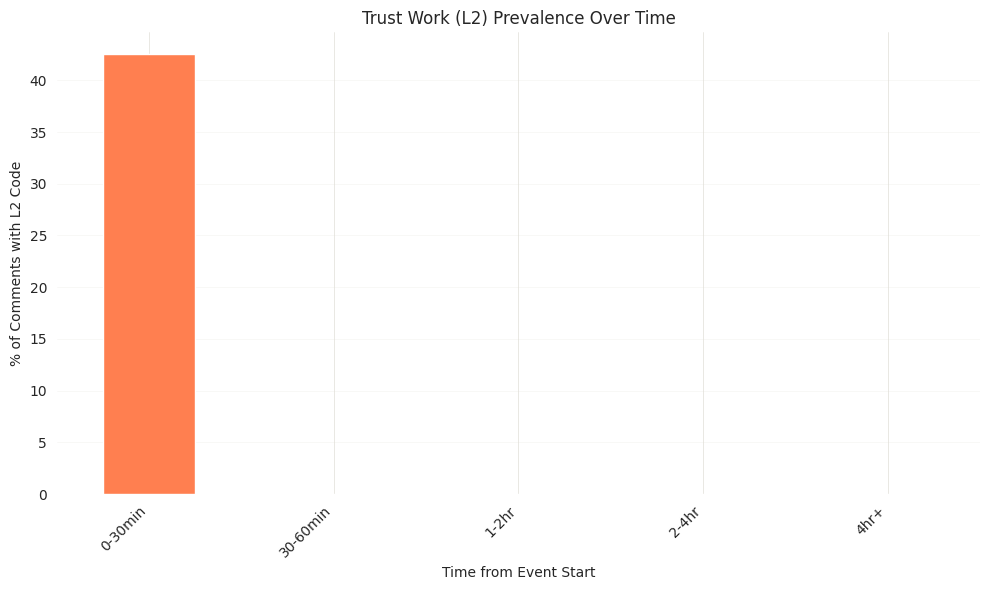


💡 Does trust work change over the course of an event?


In [ ]:
# Temporal analysis (if time_from_event_start is available)
print("="*60)
print("TEMPORAL PATTERNS")
print("="*60)

if 'time_from_event_start' in comments_clean.columns:
    # Convert to hours if needed
    comments_clean['hours_from_start'] = comments_clean['time_from_event_start'] / 3600

    # Create time bins
    comments_clean['time_bin'] = pd.cut(comments_clean['hours_from_start'],
                                      bins=[0, 0.5, 1, 2, 4, 24],
                                      labels=['0-30min', '30-60min', '1-2hr', '2-4hr', '4hr+'])

    # L2 prevalence by time
    l2_by_time = comments_clean.groupby('time_bin').apply(
        lambda x: (x['L2_code'].notna().sum() / len(x) * 100)
    )

    print("\nL2 (trust work) prevalence by time period:")
    print(l2_by_time.round(1))

    # Visualize
    plt.figure(figsize=(10, 6))
    l2_by_time.plot(kind='bar', color='coral')
    plt.title('Trust Work (L2) Prevalence Over Time')
    plt.xlabel('Time from Event Start')
    plt.ylabel('% of Comments with L2 Code')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n💡 Does trust work change over the course of an event?")
else:
    print("\n⚠️ 'time_from_event_start' column not found in comments_clean")

---
## Summary Statistics Table

**One-page summary for your paper's results section**

In [ ]:
# Create comprehensive summary table
print("="*60)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*60)

summary_stats = {
    'Dataset': ['Individual Comments', 'Conversations'],
    'n': [len(comments_clean), n_unique_conversations],
    'Most Common L1': [
        f"{l1_counts.index[0]} ({l1_pct.iloc[0]}%)",
        f"{l1_conv_counts.index[0]} ({l1_conv_pct.iloc[0]}%)"
    ],
    '% with Trust Work': [
        f"{pct_with_l2}%",
        f"{pct_conv_with_l2}%"
    ],
    'Most Common L2': [
        f"{l2_counts.index[0]} ({l2_pct_of_l2.iloc[0]}% of L2)",
        f"{l2_conv_counts.index[0]} ({l2_conv_pct_of_l2.iloc[0]}% of L2)"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n", summary_df.to_string(index=False))

print("\n" + "="*60)
print("L1 CODE DISTRIBUTION")
print("="*60)
l1_comparison = pd.DataFrame({
    'Comments (%)': l1_pct,
    'Conversations (%)': l1_conv_pct
}).fillna(0).round(1)
print("\n", l1_comparison)

print("\n" + "="*60)
print("L2 CODE DISTRIBUTION (within L2 codes only)")
print("="*60)
l2_comparison = pd.DataFrame({
    'Comments (%)': l2_pct_of_l2,
    'Conversations (%)': l2_conv_pct_of_l2
}).fillna(0).round(1)
print("\n", l2_comparison)

# Export to CSV
summary_export_path = '/content/drive/MyDrive/YOUR_FOLDER_PATH/summary_statistics.csv'
summary_df.to_csv(summary_export_path, index=False)
print(f"\n✓ Summary table exported to: {summary_export_path}")

COMPREHENSIVE SUMMARY STATISTICS

             Dataset    n                 Most Common L1 % with Trust Work                    Most Common L2
Individual Comments 1978 L1_social (42.71991911021233%)             42.5% L2_creator_question (54.7% of L2)
      Conversations  200              L1_social (44.5%)             44.0% L2_creator_question (67.0% of L2)

L1 CODE DISTRIBUTION

                   Comments (%)  Conversations (%)
L1_code                                          
L1_emotional               6.7                0.0
L1_informational          22.2                9.0
L1_operational             2.5               11.5
L1_social                 42.7               44.5
L1_understanding          25.8               35.0

L2 CODE DISTRIBUTION (within L2 codes only)

                      Comments (%)  Conversations (%)
L2_code                                             
L2_creator_question          54.7               67.0
L2_ground_truth              30.1               15.9
L2_highl